In [1]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.model.single_pass import SinglePassConfidence
from model.spatial_transformer_classifier import SpatialTransformerClassifier
from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "bigger_emnist"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}
should_gmm = True


architecture = default_architecutre_mapping[dataset]
budget = None

In [2]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [3]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']



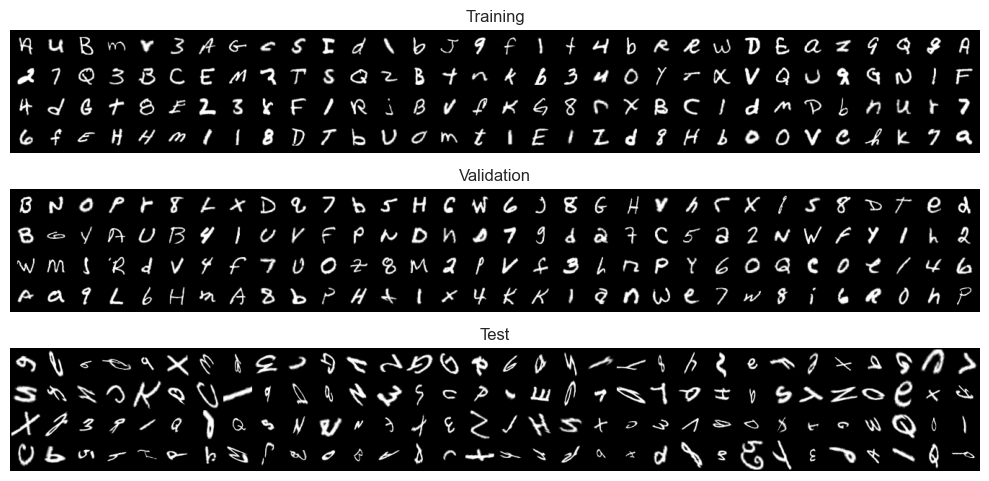

In [4]:
x = next(iter(test_loader_transformed))[0]

batch_size = next(iter(train_loader))[0].shape[0]

from utils.eval.vis import vis_dataset

vis_dataset(train_loader, val_loader, test_loader_transformed)
from experiment_thesis.main import train_and_get_model, train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture,
                                "comparison_unsupervised")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path, transform_name, f"{safe}.json")

In [5]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_emnist_bigger_extended_resnet_small.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [6]:
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [7]:
#check main model
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)
res = evaluate_base_model(model, test_loader, device)
print(res)

{'accuracy': 0.1709042489528656, 'f2_macro': 0.16747358441352844, 'f2_micro': 0.1709042489528656, 'f2_weighted': 0.16747358441352844}


{'accuracy': 0.8843085169792175, 'f2_macro': 0.8837493062019348, 'f2_micro': 0.8843085169792175, 'f2_weighted': 0.8837493062019348}


In [8]:
from utils.transforms.scale import Scale, DirectedScale, ScaleAllSame

is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]

from utils.replacer import replace_rotation_transforms_2vec,replace_scaling_transforms,replace_rotation_transforms


from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)

if dataset == "modelnet10":
    transform_seq = replace_rotation_transforms_2vec(transform_seq)

In [9]:
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic
make_deterministic(model)



In [10]:
from experiment_thesis.dataset_preperation.get_dataset import get_layer_embedding_cache_config,create_layer_embedding_cache
cache_config = get_layer_embedding_cache_config(dataset, architecture,transform_name=None,dataset_info=dataset_info)
train_cache =create_layer_embedding_cache(model, train_loader_no_shuffle,cache_config, embedding_cache_path, device=device)


In [11]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [12]:
from experiment_thesis.ood import base_prepare

base_prepare.OOD_PARAM_SAMPLERS.keys()

dict_keys(['energy', 'energy_ts', 'max_logit', 'entropy', 'max_softmax', 'differentiable_max_softmax', 'adjusted_entropy', 'Max Logit', 'MSP', 'cross_entropy', 'ash', 'gradnorm', 'laplace_prob', 'laplace_energy', 'laplace_variance', 'laplace_mutual_information', 'laplace_entropy_plus_mi', 'laplace_entropy', 'laplace_weighted', 'laplace_mi', 'laplace_best_criterion', 'laplace_entropy_gridsearch', 'laplace_energy_multi', 'mc_dropout_prob', 'mc_dropout_variance', 'mc_dropout_mi', 'mc_dropout_energy', 'mc_dropout_last_layer_prob', 'mc_dropout_last_layer_variance', 'mc_dropout_last_layer_mi', 'mc_dropout_last_layer_energy', 'mc_batchnorm_prob', 'mc_batchnorm_variance', 'mc_batchnorm_mi', 'mc_batchnorm_energy', 'mc_dropout_best_criterion', 'mc_batchnorm_best_criterion', 'mc_dropout_last_layer_best_criterion', 'react', 'react_all', 'dice', 'gaussian', 'gmm', 'gram', 'kde', 'kl_matching', 'faiss_knn', 'faiss_per_class_knn', 'knn', 'per_class_knn', 'knn_trap', 'per_class_knn_trap', 'knn_mixed',

In [13]:
detectors = ["knn","per_class_knn", "knn_mixed","per_class_knn_mixed","knn_mixed_faiss","knn_itf","vim","react","dice","ash","she","laplace_mi","laplace_energy","laplace_weighted","trust_score","openmax","mahalanobis","rmd","class_prototype","react_all","energy","per_class_prototype","single_mahalanobis","single_rmd","single_mahalanobis_individual","single_rmd_individual","mahalanobis_individual","rmd_individual","prototype_multi", "laplace_entropy","adjusted_entropy","nn_guided","nn_guided_one"]
#dont do kde to expensive, and not better.
#global protoype makes no sense over class based protoype
# lof fit is to slow, gmm is even slower or fails due to size
# gram runs out of main memory,

detectors_parameterless = ["energy_ts","entropy","kl_matching","laplace_entropy_gridsearch"]
detectors = detectors + detectors_parameterless
from experiment_thesis.dataset_preperation.basic_networks import FlexibleResNet
if not isinstance(model,FlexibleResNet):
    #remove ash and react_all as they only work with resnets
    detectors.remove("ash")
    detectors.remove("react_all")
    if "react" not in detectors:
        detectors.append("react")
    detectors.append("ash_last")



In [14]:
# python
import os
import json
import math
import torch
from typing import Tuple, Optional, Any, Dict

from experiment_thesis.ood.base_prepare import create_ood_problem, get_default_ood_params

def find_best_detector_and_instantiate(
    base_results_dir: str,
    detectors: list,
    model,
    train_cache,
    transform_seq_arg,
    dataset_info,
    architecture: str,
    device,
    val_id_loader,
    val_ood_loader,
    prefer_second: Optional[str] = None,
) -> Tuple[
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
]:
    """
    Find best detector by recorded `accuracy_mean` (preferring mean) and instantiate its OOD problem.
    Returns:
      (best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict)
    where score dict is `{"mean": float, "se": float}` (values may be math.nan if missing).
    """

    def _load_score(det_name: str) -> Optional[Dict[str, float]]:
        eval_path = os.path.join(base_results_dir, det_name, "eval_results.json")
        eval_default_path = os.path.join(base_results_dir, det_name, "eval_results_default.json")

        for p in (eval_path, eval_default_path):
            if os.path.exists(p):
                try:
                    with open(p, "r") as f:
                        data = json.load(f)
                except Exception:
                    continue
                mean = data.get("accuracy_mean")
                se = data.get("accuracy_se", data.get("accuracy_std"))  # prefer se, fall back to std
                # normalize types
                mean_val = float(mean) if isinstance(mean, (int, float)) else math.nan
                se_val = float(se) if isinstance(se, (int, float)) else math.nan
                if not math.isnan(mean_val):
                    return {"mean": mean_val, "se": se_val}
        return None

    # 1) scan detectors for optimized accuracy (use mean)
    best_detector: Optional[str] = None
    best_score_val = -math.inf
    best_score_dict: Optional[Dict[str, float]] = None
    for det in detectors:
        score_dict = _load_score(det)
        if score_dict is None:
            continue
        mean = score_dict["mean"]
        if mean > best_score_val:
            best_score_val = mean
            best_detector = det
            best_score_dict = score_dict

    # If we didn't find any valid scored detector, return Nones
    if best_detector is None:
        return None, None, None, None, None, None

    # 2) load best params for best_detector (or default if no params file)
    det_dir = os.path.join(base_results_dir, best_detector)
    params_path = os.path.join(det_dir, "best_params.json")
    best_params = None
    if os.path.exists(params_path):
        try:
            with open(params_path, "r") as f:
                best_params = json.load(f)
        except Exception:
            best_params = None

    if best_params is None:
        best_params = get_default_ood_params(best_detector)

    # 3) try load saved model states for this detector (if any)
    best_model_params = []
    prefix = os.path.join(det_dir, "best_model")
    i = 0
    while os.path.exists(f"{prefix}_{i}.pt"):
        try:
            best_model_params.append(torch.load(f"{prefix}_{i}.pt", map_location="cpu"))
        except Exception:
            pass
        i += 1

    final_kwargs = {
        "model": model,
        "train_cache": train_cache,
        "transform_seq": transform_seq_arg,
        "dataset_info": dataset_info,
        "architecture": architecture,
        "device": str(device),
        "val_id_loader": val_id_loader,
        "val_ood_loader": val_ood_loader,
    }
    if best_model_params:
        final_kwargs["model_params"] = best_model_params

    best_problem = create_ood_problem(best_detector, best_params, **final_kwargs)

    # 4) prepare the second problem: choose the better of energy vs entropy by recorded performance
    if prefer_second and prefer_second in detectors:
        second_choice = prefer_second
        second_score_dict = _load_score(second_choice)
    else:
        candidates = [d for d in ("energy", "entropy") if d in detectors]
        second_choice = None
        best_cand_val = -math.inf
        second_score_dict = None
        for c in candidates:
            sdict = _load_score(c)
            if sdict is not None and sdict["mean"] > best_cand_val:
                best_cand_val = sdict["mean"]
                second_choice = c
                second_score_dict = sdict

    # avoid selecting same detector twice
    if second_choice == best_detector:
        other = "entropy" if best_detector == "energy" else "energy"
        if other in detectors:
            other_score = _load_score(other)
            if other_score is not None:
                second_choice = other
                second_score_dict = other_score
            else:
                second_choice = None
                second_score_dict = None
        else:
            second_choice = None
            second_score_dict = None

    if second_choice is None:
        second_problem = None
    else:
        det2_dir = os.path.join(base_results_dir, second_choice)
        params2_path = os.path.join(det2_dir, "best_params.json")
        params2 = None
        if os.path.exists(params2_path):
            try:
                with open(params2_path, "r") as f:
                    params2 = json.load(f)
            except Exception:
                params2 = None
        if params2 is None:
            params2 = get_default_ood_params(second_choice)

        model_params2 = []
        prefix2 = os.path.join(det2_dir, "best_model")
        j = 0
        while os.path.exists(f"{prefix2}_{j}.pt"):
            try:
                model_params2.append(torch.load(f"{prefix2}_{j}.pt", map_location="cpu"))
            except Exception:
                pass
            j += 1

        final_kwargs2 = dict(final_kwargs)
        if model_params2:
            final_kwargs2["model_params"] = model_params2

        second_problem = create_ood_problem(second_choice, params2, **final_kwargs2)

    return best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict

# Example call (update unpacking to 6 values)
base_results_dir = os.path.join(
    current_path,
    "experiment_files",
    "results",
    "comparison_unsupervised",
    str(dataset),
    str(architecture),
    getattr(dataset_info, "transform_seq_name", "default"),
)

best_detector, best_problem, best_score, second_choice, second_problem, second_score = find_best_detector_and_instantiate(
    base_results_dir=base_results_dir,
    detectors=detectors,
    model=model,
    train_cache=train_cache,
    transform_seq_arg=transform_seq,
    dataset_info=dataset_info,
    architecture=architecture,
    device=device,
    val_id_loader=val_loader_transformed,
    val_ood_loader=val_loader_transformed,
)

In [15]:
#here we do the following calculate the accuracy on the test set, then calculate on the transformed test set. We also store the confidence valeus
#then we do the optimiztation to find which ones we can transform to get better accuracy.
#we then draw the curve over the threshold when we switch from doing no optimization to doing optimization, this should drop the accuracy on the test set but increase on the transformed test set.



In [16]:
transform_seq_spatial = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
).to(device)
from utils.transforms.scale import Scale, DirectedScale, ScaleAllSame

is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]




from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq2 = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)

if dataset == "modelnet10":
    from utils.transforms.rotation import RotationSkew3D
    transform_seq2 = replace_rotation_transforms_2vec(transform_seq2)
else:
    transform_seq2 = replace_rotation_transforms(transform_seq)
if dataset=="coil100":
    transform_seq2 = replace_scaling_transforms(transform_seq2, replace_scale=False)
transform_seq_spatial = transform_seq2




In [17]:
train_loader_augmented = dataset_dict.get('train_loader_augmented', None)

In [18]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

In [19]:
layer,layer_io = get_network_layer(dataset_info, architecture, 1, num_classes=None, num_rotations=8)

In [20]:
from embedding_cache import LayerEmbeddingCache
cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))

dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True)
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=layer_io, flatten=True)


In [21]:
from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule
from confidence.direct.targeted import CrossEntropyConfidence
from confidence.model.single_pass import SinglePassConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
from confidence.unsupervised.classic.prototype import ClassPrototypeConfidence
from confidence.control.split import TrueLabelSplitConfidence
from utils.transformation_problem import TransformationProblem

nn_pytorch_pretrained = ClassPrototypeConfidence(metric="cosine")
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.to(device)

conf_split_pretrained = TrueLabelSplitConfidence(nn_pytorch_pretrained, CrossEntropyConfidence(), mult=False,a=10,b=1)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_guided = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq_spatial,consolidate_method="consolidate_simple")
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [22]:
from utils.transformation_problem import TransformationProblem


In [23]:
from dataset.geometric_wrapper import TransformParamDataset
import search.shgo
import importlib
import tqdm

if should_gmm:
    train_loader_transformed_no_shuffle = dataset_dict['train_loader_transformed_no_shuffle']


    import search.shgo
    import importlib
    import tqdm
    import os
    import pickle


    importlib.reload(search.shgo)

    # Define cache path
    regression_cache_path = os.path.join(
        embedding_cache_path,
        f"regression_params_{dataset}_{architecture}_{transform_name}.pkl"
    )

    if os.path.exists(regression_cache_path):
        print(f"Loading cached regression parameters from {regression_cache_path}")
        with open(regression_cache_path, 'rb') as f:
            cache_data = pickle.load(f)
            regression_target = cache_data['regression_target']
            test_acc_sim = cache_data['test_acc_sim']
    else:
        print("Computing regression parameters (this may take a while)...")
        di = search.shgo.SHGO(selection_method="topk", initial_samples=108+120, local_runs=2, local_max_steps=3, local_opt_kwargs={"lr":0.1})
        if dataset == "tu_berlin":
            di = search.shgo.SHGO(selection_method="topk", initial_samples=240, local_runs=1, local_max_steps=0, local_opt_kwargs={"lr":0.1})

        model.eval().cuda()

        regression_target = []
        test_acc_sim = 0.0
        counter = 0
        problem_guided.max_batch_size =dataset_info.batch_size_search
        bar = tqdm.tqdm(train_loader_transformed_no_shuffle)
        first=True
        print()
        try:
            for data, target in bar:
                data, target = data.cuda(), target.cuda()
                res = di.optimize(problem_guided, data.cuda(), y=target.cuda())
                zw = transform_seq_spatial.normalize(res[0])
                regression_target.append(zw.detach().cpu())

                # Apply the transformation and get predictions
                x_transformed2 = problem_guided.transform(data.cuda(), zw)
                logits = model(x_transformed2)
                output = logits.argmax(dim=-1)
                test_acc_sim += output.eq(target).sum().item()
                counter += output.shape[0]
                #update bar with intermediate accuracy
                if first and is_image_data:
                    first=False
                    #plot
                    import matplotlib.pyplot as plt
                    grid_orig = torchvision.utils.make_grid(data.cpu(), nrow=8, normalize=True, scale_each=True)
                    grid_transformed = torchvision.utils.make_grid(x_transformed2.cpu(), nrow=8, normalize=True, scale_each=True)
                    plt.figure(figsize=(12, 6))
                    plt.subplot(1, 2, 1)
                    plt.title("Original Images")
                    plt.imshow(grid_orig.permute(1, 2, 0))
                    plt.axis('off')
                    plt.subplot(1, 2, 2)
                    plt.imshow(grid_transformed.permute(1, 2, 0))
                    plt.title("Transformed Images")
                    plt.show()
                    print()
                #flush bar
                bar.refresh()
                bar.set_description(f"Intermediate transformed accuracy: {test_acc_sim / counter:.4f}")

        finally:
            bar.close()

        test_acc_sim /= counter
        regression_target = torch.cat(regression_target, dim=0)

        # Save to cache
        os.makedirs(os.path.dirname(regression_cache_path), exist_ok=True)
        with open(regression_cache_path, 'wb') as f:
            pickle.dump({
                'regression_target': regression_target,
                'test_acc_sim': test_acc_sim
            }, f)
        print(f"Cached regression parameters to {regression_cache_path}")



    regression_dataset = TransformParamDataset(train_loader_transformed_no_shuffle.dataset, regression_target)
    regression_dataloader = torch.utils.data.DataLoader(
        regression_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        persistent_workers=True
    )

    print(f'With class knowledge we can define a canonical representation of the data: {test_acc_sim}.')



Loading cached regression parameters from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\embedding_cache\regression_params_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default.pkl
With class knowledge we can define a canonical representation of the data: 0.9939913317572892.


In [24]:

dataset_affine =train_loader_transformed.dataset

all_T = []
for i in range(len(dataset_affine)):
    x, y, T = dataset_affine.__getitem__(i,return_transformation=True)
    all_T.append(T)
all_T = torch.stack(all_T, dim=0)


regression_dataset_true = TransformParamDataset(train_loader_transformed_no_shuffle.dataset, all_T)

In [25]:
dataset_affine_val =val_loader_transformed.dataset
all_T_val = []
for i in range(len(dataset_affine_val)):
    x, y, T = dataset_affine_val.__getitem__(i,return_transformation=True)
    all_T_val.append(T)
all_T_val = torch.stack(all_T_val, dim=0)
regression_dataset_true_val = TransformParamDataset(val_loader_transformed.dataset, all_T_val)

In [26]:
model.cuda().eval()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [27]:
regression_true_dataloader = torch.utils.data.DataLoader(
    regression_dataset_true,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    persistent_workers=True
)

regression_true_val_dataloader = torch.utils.data.DataLoader(
    regression_dataset_true_val,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    persistent_workers=True
)

In [28]:
#disable grad for main model
for param in model.parameters():
    param.requires_grad = False

In [29]:
import tqdm
def evaluate_spatial_transformer(spatial_transformer, data_loader, device):
    spatial_transformer.eval().to(device)
    make_deterministic(spatial_transformer)
    correct = 0
    total = 0
    for data, target in tqdm.tqdm(data_loader):
        data, target = data.to(device), target.to(device)
        outputs = spatial_transformer.transform_input(data)
        outputs = model(outputs)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    return correct / total

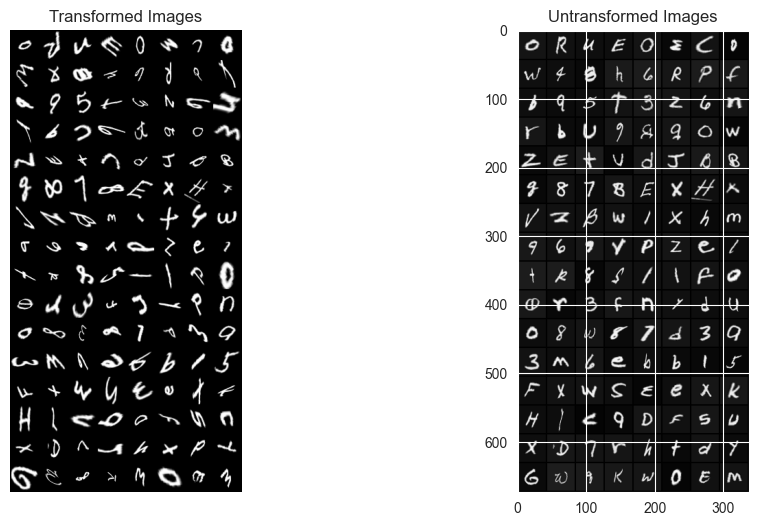

In [30]:
#test the regression true dataset
if is_image_data:
    x,T,y =next(iter(regression_dataloader))
    T = transform_seq_spatial(T)
    x_untransformed = transform_seq_spatial.application_method(x, T)

    plt.figure(figsize=(12, 6))
    grid_orig = torchvision.utils.make_grid(x.cpu(), nrow=8, normalize=True, scale_each=True)
    grid_untransformed = torchvision.utils.make_grid(x_untransformed.cpu(), nrow=8, normalize=True, scale_each=True)
    plt.subplot(1, 2, 1)
    plt.title("Transformed Images")
    plt.imshow(grid_orig.permute(1, 2, 0))
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(grid_untransformed.permute(1, 2, 0))
    plt.title("Untransformed Images")
    plt.show()






In [31]:
def benchmark_speed_spatial_transformer(model,data_shape, n_runs=100,use_forward_with_loss=False,y_shape=None):
    model.eval().to(device)
    make_deterministic(model)
    import time
    data = next(iter(test_loader))[0].to(device)
    start_time = time.time()
    for _ in range(n_runs):
            if use_forward_with_loss:
                _ = model.forward_with_loss(data, torch.zeros(y_shape).to(device))
            else:
                _ = model(data)
    end_time = time.time()
    total_time = end_time - start_time
    return total_time / n_runs

In [32]:
res = benchmark_speed_spatial_transformer(model,(batch_size, *dataset_info.input_size), n_runs=100)
res = benchmark_speed_spatial_transformer(model,(batch_size, *dataset_info.input_size), n_runs=1000)
print(res)

0.005152565002441406


In [33]:
from utils.sampling import _get_at_path, _set_at_path
import torch
from typing import Any, Callable, Optional, Tuple, Union


class BatchPositiveRateSampler(torch.nn.Module):
    def __init__(
        self,
        strategy,
        x_index: Union[int, Tuple[Union[int, str], ...]] = 0,
        y_index: Union[int, Tuple[Union[int, str], ...]] = 1,
        negative_value: Union[int, float] = -1,
        positive_rate: float = 0.5,
        transform_true_function=None,
        augment_function: Optional[Callable[[torch.Tensor], torch.Tensor]] = None,
        decision_strategy=None,
        return_params: bool = False,
    ):
        """
        Keeps the same batch size but replaces a fraction of positives with negatives.

        Args:
            strategy: object providing .sample(X) or .sample_and_params(X)
            positive_rate: fraction of positives to keep (0–1).
                           At least 1 positive kept if >0.
        """
        super().__init__()
        self.strategy = strategy
        self.x_index = (x_index,) if isinstance(x_index, int) else tuple(x_index)
        self.y_index = (y_index,) if isinstance(y_index, int) else tuple(y_index)
        self.negative_value = negative_value
        self.positive_rate = positive_rate
        self.transform_true_function = transform_true_function
        self.augment_function = augment_function
        self.decision_strategy = decision_strategy
        self.return_params = return_params


    @torch.no_grad()
    def forward(self, batch: Any):
        if isinstance(batch, torch.Tensor):
            raise ValueError("BatchPositiveRateSampler expects a structured batch, not a tensor.")

        X = _get_at_path(batch, self.x_index).float()   # <- enforce float32
        y = _get_at_path(batch, self.y_index)
        batch_size = X.size(0)

        # --- Determine positive/negative counts ---
        if self.positive_rate <= 0:
            num_pos = 0
        else:
            num_pos = max(1, int(batch_size * self.positive_rate))
        num_neg = batch_size - num_pos

        # --- Random index split ---
        perm = torch.randperm(batch_size, device=X.device)
        pos_idx = perm[:num_pos]
        neg_idx = perm[num_pos:]

        # --- Positives ---
        X_pos = X[pos_idx]
        if self.transform_true_function is not None:
            X_pos = self.transform_true_function(X_pos).float()

        # --- Negatives ---
        if num_neg > 0:
            if self.return_params:
                X_neg, T_neg = self.strategy.sample_and_params(X[neg_idx])
                X_neg = X_neg.float()
                T_neg = T_neg.float()
            else:
                X_neg = self.strategy.sample(X[neg_idx]).float()
        else:
            X_neg = torch.empty_like(X[:0]).float()
            if self.return_params:
                T_neg = torch.empty_like(self.strategy.identity_transform(1)[:0]).float()

        # --- Combine ---
        both = X.clone().float()
        both[pos_idx] = X_pos
        if num_neg > 0:
            both[neg_idx] = X_neg

        if self.augment_function is not None:
            both = self.augment_function(both).float()

        modified_batch = _set_at_path(batch, self.x_index, both)

        # --- Update labels ---
        if y is not None:
            modified_y = y.clone()
            if num_neg > 0:
                modified_y[neg_idx] = self.negative_value

            if self.decision_strategy is not None:
                in_dist = modified_y >= 0
                modified_y = self.decision_strategy(both, in_dist, y)

            modified_batch = _set_at_path(modified_batch, self.y_index, modified_y)

        # --- Return params if requested ---
        if self.return_params:
            T_pos = self.strategy.identity_transform(num_pos).float()
            if num_neg > 0:
                T_all = torch.empty(
                    (batch_size, *T_pos.shape[1:]),
                    dtype=torch.float32,
                    device=T_pos.device,
                )
                T_all[pos_idx] = T_pos
                T_all[neg_idx] = T_neg.float()
            else:
                T_all = self.strategy.identity_transform(batch_size).float()
            return modified_batch, T_all

        return modified_batch



In [34]:
if dataset=="modelnet10":
    dataset_info.epochs=30

In [35]:
from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy

from model.classifier import MyProgressBar
from utils.transformation_problem import TransformationProblem
import pytorch_lightning as pl

spatial_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_neg_only.pt"
)

localization_dim = 128
localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)

#different dec strat that returns the true label for all
def dec_strat(x, idd, y_true):
    return y_true

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None

negative_sampling_module = BatchPositiveRateSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =None, augment_function=None,
    decision_strategy=dec_strat,return_params=True,positive_rate=0.0
)


# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    make_deterministic(model,random=True)
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 3e-4},
        optimizer_class = torch.optim.Adam,
        negative_sampling_module=negative_sampling_module,
        l2_weight=0.0,
        train_mode=1,
        target_param_form="matrix_inverted",
        use_l2_instead_of_per_transform=True
    )






    # Train the spatial transformer model on transformed data
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        monitor="val_acc",
        dirpath=None,
        filename="best-checkpoint",
        save_top_k=1,
        mode="max",
        verbose=True,
    )


    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=dataset_info.epochs,
        precision="16-mixed" if dataset != "modelnet10" else "32",
        callbacks=[MyProgressBar(),checkpoint_callback]
    )
    if dataset == "tu_berlin":
        model.eval()
    trainer.fit(spatial_transformer, train_loader, regression_true_val_dataloader)
    make_deterministic(model)
    # --- Load best model automatically ---
    best_model_path = checkpoint_callback.best_model_path
    print(f"Loading best model from checkpoint: {best_model_path}")
    spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
        best_model_path,
        main_model=model,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
        # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()

res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
print(f"Spatial transformer test accuracy on transformed data: {res}")
print(f"Spatial transformer test accuracy on original data: {res2}")



Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_neg_only.pt


100%|██████████| 147/147 [00:02<00:00, 72.76it/s]

Spatial transformer test accuracy on transformed data: 0.5938829787234042
Spatial transformer test accuracy on original data: 0.6656382978723404


In [36]:
from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy

from model.classifier import MyProgressBar
from utils.transformation_problem import TransformationProblem
import pytorch_lightning as pl

spatial_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_both.pt"
)

localization_dim = 128
localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)

#different dec strat that returns the true label for all
def dec_strat(x, idd, y_true):
    return y_true

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None

negative_sampling_module = BatchPositiveRateSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =None, augment_function=None,
    decision_strategy=dec_strat,return_params=True,positive_rate=0.125
)


# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    make_deterministic(model,random=True)
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 5e-4},
        optimizer_class = torch.optim.Adam,
        negative_sampling_module=negative_sampling_module,
        l2_weight=0.0,
        train_mode=1,
        target_param_form="matrix_inverted",
    )






    # Train the spatial transformer model on transformed data
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        monitor="val_acc",
        dirpath=None,
        filename="best-checkpoint",
        save_top_k=1,
        mode="max",
        verbose=True,
    )


    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=dataset_info.epochs,
        precision="16-mixed" if dataset != "modelnet10" else "32",
        callbacks=[MyProgressBar(),checkpoint_callback]
    )
    trainer.fit(spatial_transformer, train_loader, regression_true_val_dataloader)
    make_deterministic(model)
    # --- Load best model automatically ---
    best_model_path = checkpoint_callback.best_model_path
    print(f"Loading best model from checkpoint: {best_model_path}")
    spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
        best_model_path,
        main_model=model,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
        # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()

res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
print(f"Spatial transformer test accuracy on transformed data: {res}")
print(f"Spatial transformer test accuracy on original data: {res2}")


Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_both.pt


100%|██████████| 147/147 [00:02<00:00, 71.16it/s]

Spatial transformer test accuracy on transformed data: 0.5915957446808511
Spatial transformer test accuracy on original data: 0.8645744680851064


In [37]:
from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy

from model.classifier import MyProgressBar
from utils.transformation_problem import TransformationProblem
import pytorch_lightning as pl

spatial_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_lr.pt"
)

localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)

#different dec strat that returns the true label for all
def dec_strat(x, idd, y_true):
    return y_true

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None

negative_sampling_module = BatchPositiveRateSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =None, augment_function=None,
    decision_strategy=dec_strat,return_params=True,positive_rate=0.125
)


# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    make_deterministic(model,random=True)
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 3e-4},
        optimizer_class = torch.optim.Adam,
        negative_sampling_module=negative_sampling_module,
        l2_weight=0,
        train_mode=1,
        target_param_form="matrix_inverted",
    )
    # Train the spatial transformer model on transformed data
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        monitor="val_acc",
        dirpath=None,
        filename="best-checkpoint",
        save_top_k=1,
        mode="max",
        verbose=True,
    )


    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=dataset_info.epochs,
        precision="16-mixed" if dataset != "modelnet10" else "32",
        callbacks=[MyProgressBar(),checkpoint_callback]
    )
    trainer.fit(spatial_transformer, train_loader, regression_true_val_dataloader)
    make_deterministic(model)
    # --- Load best model automatically ---
    best_model_path = checkpoint_callback.best_model_path
    print(f"Loading best model from checkpoint: {best_model_path}")
    spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
        best_model_path,
        main_model=model,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
        # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()


res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
print(f"Spatial transformer test accuracy on transformed data: {res}")
print(f"Spatial transformer test accuracy on original data: {res2}")
del spatial_transformer




Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr.pt


100%|██████████| 147/147 [00:02<00:00, 72.67it/s]

Spatial transformer test accuracy on transformed data: 0.6096276595744681
Spatial transformer test accuracy on original data: 0.8032446808510638


In [38]:
from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy

from model.classifier import MyProgressBar
from utils.transformation_problem import TransformationProblem
import pytorch_lightning as pl

spatial_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_lr5.pt"
)

localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)

#different dec strat that returns the true label for all
def dec_strat(x, idd, y_true):
    return y_true

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None

negative_sampling_module = BatchPositiveRateSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =None, augment_function=None,
    decision_strategy=dec_strat,return_params=True,positive_rate=0.125
)


# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    make_deterministic(model,random=True)
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 1e-4},
        optimizer_class = torch.optim.Adam,
        negative_sampling_module=negative_sampling_module,
        l2_weight=0.00,
        train_mode=1,
        target_param_form="matrix_inverted",
    )
    # Train the spatial transformer model on transformed data
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        monitor="val_acc",
        dirpath=None,
        filename="best-checkpoint",
        save_top_k=1,
        mode="max",
        verbose=True,
    )


    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=dataset_info.epochs,
        precision="16-mixed" if dataset != "modelnet10" else "32",
        callbacks=[MyProgressBar(),checkpoint_callback]
    )
    trainer.fit(spatial_transformer, train_loader, regression_true_val_dataloader)
    make_deterministic(model)
    # --- Load best model automatically ---
    best_model_path = checkpoint_callback.best_model_path
    print(f"Loading best model from checkpoint: {best_model_path}")
    spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
        best_model_path,
        main_model=model,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
        # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()

res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
print(f"Spatial transformer test accuracy on transformed data: {res}")
print(f"Spatial transformer test accuracy on original data: {res2}")
del spatial_transformer

Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr5.pt


100%|██████████| 147/147 [00:02<00:00, 72.80it/s]

Spatial transformer test accuracy on transformed data: 0.5813297872340426
Spatial transformer test accuracy on original data: 0.7893617021276595


In [39]:
if is_image_data:
    from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
    from utils.sampling_strategy import TransformLatentSamplingStrategy

    from model.classifier import MyProgressBar
    from utils.transformation_problem import TransformationProblem
    import pytorch_lightning as pl

    spatial_model_path = os.path.join(
        model_dir_path,
        f"spatial_transformer_{dataset}_{architecture}_{transform_name}_augment.pt"
    )

    localization_net = get_network(
        dataset_info,
        architecture,
        num_classes=localization_dim
    ).to(device)

    #different dec strat that returns the true label for all
    def dec_strat(x, idd, y_true):
        return y_true

    if is_image_data:
        transform_true_function = small_affine_augment_2d
        affine_augment = ComposeAugmentations([
            lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                             blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                             usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                             usm_amount_range=(0.5, 1.3), clamp=True),

        ])
    else:
        transform_true_function = None
        affine_augment = None

    negative_sampling_module = BatchPositiveRateSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=dec_strat,return_params=True,positive_rate=0.125
    )


    # Check if spatial transformer model exists
    if os.path.exists(spatial_model_path) and True:
        print(f"Loading spatial transformer model from {spatial_model_path}")
        spatial_transformer = SpatialTransformerClassifier(
            main_model=model,
            transformation_problem=TransformationProblem(None,transform_seq_spatial),
            localization_net=localization_net,
            localization_dim=localization_dim,
            freeze_main=True  # Freeze the base model
        )
        spatial_transformer.load_state_dict(torch.load(spatial_model_path))
        make_deterministic(spatial_transformer)
        spatial_transformer.to(device).eval()
    else:
        print(f"Training spatial transformer model and will save to {spatial_model_path}")
        make_deterministic(model,random=True)
        spatial_transformer = SpatialTransformerClassifier(
            main_model=model,
            localization_net=localization_net,
            localization_dim=localization_dim,
            transformation_problem=TransformationProblem(None,transform_seq_spatial),
            freeze_main=True,  # Freeze the base model
            optimizer_params={"lr": 3e-4},
            optimizer_class = torch.optim.Adam,
            negative_sampling_module=negative_sampling_module,
            l2_weight=0.00,
            train_mode=1,
            target_param_form="matrix_inverted",
        )
        # Train the spatial transformer model on transformed data
        checkpoint_callback = pl.callbacks.ModelCheckpoint(
            monitor="val_acc",
            dirpath=None,
            filename="best-checkpoint",
            save_top_k=1,
            mode="max",
            verbose=True,
        )


        trainer = pl.Trainer(
            accelerator="cuda",
            max_epochs=dataset_info.epochs,
            precision="16-mixed" if dataset != "modelnet10" else "32",
            callbacks=[MyProgressBar(),checkpoint_callback]
        )
        trainer.fit(spatial_transformer, train_loader, regression_true_val_dataloader)
        make_deterministic(model)
        # --- Load best model automatically ---
        best_model_path = checkpoint_callback.best_model_path
        print(f"Loading best model from checkpoint: {best_model_path}")
        spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
            best_model_path,
            main_model=model,
            transformation_problem=TransformationProblem(None, transform_seq_spatial),
            localization_net=localization_net,
            localization_dim=localization_dim,
            freeze_main=True,
        )
            # Save the spatial transformer model
        torch.save(spatial_transformer.state_dict(), spatial_model_path)
        print(f"Spatial transformer model saved to {spatial_model_path}")
        make_deterministic(spatial_transformer)
        spatial_transformer.to(device).eval()
    res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
    res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
    print(f"Spatial transformer test accuracy on transformed data: {res}")
    print(f"Spatial transformer test accuracy on original data: {res2}")
    del spatial_transformer

Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_augment.pt


100%|██████████| 147/147 [00:02<00:00, 72.42it/s]

Spatial transformer test accuracy on transformed data: 0.5909574468085106
Spatial transformer test accuracy on original data: 0.726436170212766


In [40]:
#compare both with lr versions
path_both = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_both.pt"
)
path_lr = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_lr.pt"
)



localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)
model_both = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )

model_both.load_state_dict(torch.load(path_both))
make_deterministic(model_both)
model_both.to(device).eval()

res_both = evaluate_spatial_transformer(model_both, test_loader_transformed, device)
res2_both = evaluate_spatial_transformer(model_both, test_loader, device)
print(f"Spatial transformer BOTH test accuracy on transformed data: {res_both}")
print(f"Spatial transformer BOTH test accuracy on original data: {res2_both}")

del model_both

localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)
model_lr = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
model_lr.load_state_dict(torch.load(path_lr))
make_deterministic(model_lr)
model_lr.to(device).eval()
res_lr = evaluate_spatial_transformer(model_lr, test_loader_transformed, device)
res2_lr = evaluate_spatial_transformer(model_lr, test_loader, device)
print(f"Spatial transformer LR test accuracy on transformed data: {res_lr}")
print(f"Spatial transformer LR test accuracy on original data: {res2_lr}")
del model_lr

lr_better = res_lr > res_both
lr_better_orig = res2_lr > res2_both
print(f"LR model better on transformed data: {lr_better}")
print(f"LR model better on original data: {lr_better_orig}")




100%|██████████| 147/147 [00:02<00:00, 70.76it/s]


Spatial transformer BOTH test accuracy on transformed data: 0.5915957446808511
Spatial transformer BOTH test accuracy on original data: 0.8645744680851064


100%|██████████| 147/147 [00:02<00:00, 72.34it/s]

Spatial transformer LR test accuracy on transformed data: 0.6096276595744681
Spatial transformer LR test accuracy on original data: 0.8032446808510638
LR model better on transformed data: True
LR model better on original data: False


In [41]:
# python
# Evaluate `both`, `lr` and `lr5`, pick the best (by transformed accuracy) and set lr_next/path_prev_next.
files_to_check = {
    "both": f"spatial_transformer_{dataset}_{architecture}_{transform_name}_both.pt",
    "lr":   f"spatial_transformer_{dataset}_{architecture}_{transform_name}_lr.pt",
    "lr5":  f"spatial_transformer_{dataset}_{architecture}_{transform_name}_lr5.pt",
}

lr_map = {"both": 5e-4, "lr": 3e-4, "lr5": 1e-4}

results = {}

for label, fname in files_to_check.items():
    path = os.path.join(model_dir_path, fname)
    if not os.path.exists(path):
        print(f"Missing `{path}`; skipping `{label}`")
        continue
    try:
        localization_net = get_network(dataset_info, architecture, num_classes=localization_dim).to(device)
        st = SpatialTransformerClassifier(
            main_model=model,
            transformation_problem=TransformationProblem(None, transform_seq_spatial),
            localization_net=localization_net,
            localization_dim=localization_dim,
            freeze_main=True
        )
        sd = torch.load(path, map_location="cpu")
        st.load_state_dict(sd)
        make_deterministic(st)
        st.to(device).eval()

        res_t = evaluate_spatial_transformer(st, test_loader_transformed, device)
        res_o = evaluate_spatial_transformer(st, test_loader, device)
        print(f"{label:4s} | transformed: {res_t:.4f} | original: {res_o:.4f} | file: ` {fname} `")
        results[label] = {"transformed": res_t, "original": res_o, "path": path}

    except Exception as e:
        print(f"Failed to load/eval `{path}`: {e}")

    finally:
        try:
            del st
        except Exception:
            pass
        torch.cuda.empty_cache()

if results:
    # choose best by transformed accuracy
    best_label = max(results.keys(), key=lambda k: results[k]["transformed"])
    lr_next = lr_map[best_label]
    path_prev_next = os.path.join(model_dir_path, files_to_check[best_label])
    print(f"Best: `{best_label}` -> lr_next = {lr_next}, path_prev_next = `{path_prev_next}`")
else:
    print("No models evaluated; keeping defaults.")

100%|██████████| 147/147 [00:02<00:00, 71.91it/s]


both | transformed: 0.5916 | original: 0.8646 | file: ` spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_both.pt `


100%|██████████| 147/147 [00:02<00:00, 71.64it/s]


lr   | transformed: 0.6096 | original: 0.8032 | file: ` spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr.pt `


100%|██████████| 147/147 [00:02<00:00, 70.30it/s]

lr5  | transformed: 0.5813 | original: 0.7894 | file: ` spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr5.pt `
Best: `lr` -> lr_next = 0.0003, path_prev_next = `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr.pt`


Next cell test performance when not using augmenation but a single transformed with paramters foudn using optimization.

In [42]:
from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy

from model.classifier import MyProgressBar
from utils.transformation_problem import TransformationProblem
import pytorch_lightning as pl

spatial_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_opt_direct.pt"
)

localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)


# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    make_deterministic(model,random=True)
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": lr_next},
        optimizer_class = torch.optim.Adam,
        negative_sampling_module=None,
        l2_weight=0.00,
        train_mode=1,
        target_param_form="params",
    )
    # Train the spatial transformer model on transformed data
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        monitor="val_acc",
        dirpath=None,
        filename="best-checkpoint",
        save_top_k=1,
        mode="max",
        verbose=True,
    )


    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=dataset_info.epochs,
        precision="16-mixed" if dataset != "modelnet10" else "32",
        callbacks=[MyProgressBar(),checkpoint_callback]
    )
    trainer.fit(spatial_transformer, regression_dataloader, val_loader_transformed)
    make_deterministic(model)
    # --- Load best model automatically ---
    best_model_path = checkpoint_callback.best_model_path
    print(f"Loading best model from checkpoint: {best_model_path}")
    spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
        best_model_path,
        main_model=model,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
        # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()


res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
print(f"Spatial transformer test accuracy on transformed data: {res}")
print(f"Spatial transformer test accuracy on original data: {res2}")

Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_opt_direct.pt


100%|██████████| 147/147 [00:02<00:00, 72.66it/s]

Spatial transformer test accuracy on transformed data: 0.4724468085106383
Spatial transformer test accuracy on original data: 0.5829787234042553


Finetuning tests

In [43]:
model = get_network(dataset_info, architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train = f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model, model_dir_path, modelname, train_loader, val_loader, trainer_kwargs={
    "accelerator": "auto",
    "max_epochs": dataset_info.epochs,
    "precision": "16-mixed",
}, load_if_exists=True)

compare_model = spatial_transformer.main_model
import torch


def models_have_same_weights(m1, m2):
    for (n1, p1), (n2, p2) in zip(m1.state_dict().items(), m2.state_dict().items()):
        if not torch.allclose(p1, p2):
            print(f"❌ Difference found in layer: {n1}")
            print(f"Max abs diff: {(p1 - p2).abs().max().item()}")
            return False
    print("✅ All weights are identical!")
    return True


models_have_same_weights(model, compare_model)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_emnist_bigger_extended_resnet_small.safetensors
✅ All weights are identical!


True

In [44]:
from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy

from model.classifier import MyProgressBar
from utils.transformation_problem import TransformationProblem
import pytorch_lightning as pl

spatial_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_lr_cross.pt"
)

localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)
#load state dict from previous model
previous_model_path = os.path.join(
    model_dir_path,
    path_prev_next
)

#load previos model
spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
)
spatial_transformer.load_state_dict(torch.load(previous_model_path))

regression_net = spatial_transformer.regression_net


spatial_transformer=None
negative_sampling_module=BatchPositiveRateSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =None, augment_function=None,
    decision_strategy=dec_strat,return_params=True,positive_rate=0.125
)


# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.regression_net = regression_net
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    make_deterministic(model,random=True)
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        negative_sampling_module=negative_sampling_module,
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 3e-5},
        optimizer_class = torch.optim.Adam,
        l2_weight=0.00,
        train_mode=0.0,
        target_param_form="params",
    )


    spatial_transformer.regression_net = regression_net
    res = evaluate_spatial_transformer(spatial_transformer, val_loader_transformed, device)
    print(f"Initial validation accuracy before further fine-tuning: {res}")
    print("Using previous regression net weights for further fine-tuning.")

    # Train the spatial transformer model on transformed data
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        monitor="val_acc",
        dirpath=None,
        filename="best-checkpoint",
        save_top_k=1,
        mode="max",
        verbose=True,
    )


    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=1,
        precision="16-mixed" if dataset != "modelnet10" else "32",
        callbacks=[MyProgressBar(),checkpoint_callback]
    )
    if dataset=="tu_berlin":
        model.train()
    spatial_transformer.train()
    trainer.fit(spatial_transformer, train_loader, val_loader_transformed)
    if dataset=="tu_berlin":
        model.eval()
    make_deterministic(model)
    # --- Load best model automatically ---
    best_model_path = checkpoint_callback.best_model_path
    print(f"Loading best model from checkpoint: {best_model_path}")
    spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
        best_model_path,
        main_model=model,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
        # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()


res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
print(f"Spatial transformer test accuracy on transformed data: {res}")
print(f"Spatial transformer test accuracy on original data: {res2}")




Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr_cross.pt


100%|██████████| 147/147 [00:02<00:00, 72.28it/s]

Spatial transformer test accuracy on transformed data: 0.6227127659574468
Spatial transformer test accuracy on original data: 0.8629255319148936


In [45]:
model = get_network(dataset_info, architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train = f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model, model_dir_path, modelname, train_loader, val_loader, trainer_kwargs={
    "accelerator": "auto",
    "max_epochs": dataset_info.epochs,
    "precision": "16-mixed",
}, load_if_exists=True)

compare_model = spatial_transformer.main_model
import torch


def models_have_same_weights(m1, m2):
    for (n1, p1), (n2, p2) in zip(m1.state_dict().items(), m2.state_dict().items()):
        if not torch.allclose(p1, p2):
            print(f"❌ Difference found in layer: {n1}")
            print(f"Max abs diff: {(p1 - p2).abs().max().item()}")
            raise Exception("Models differ")
            return False
    print("✅ All weights are identical!")
    return True


models_have_same_weights(model, compare_model)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_emnist_bigger_extended_resnet_small.safetensors
✅ All weights are identical!


True

In [46]:
from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy

from model.classifier import MyProgressBar
from utils.transformation_problem import TransformationProblem
import pytorch_lightning as pl

spatial_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_lr_cross2.pt"
)

localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)
#load state dict from previous model
previous_model_path = os.path.join(
    model_dir_path,
    path_prev_next
)

#load previos model
spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
)
spatial_transformer.load_state_dict(torch.load(previous_model_path))

regression_net = spatial_transformer.regression_net


spatial_transformer=None
negative_sampling_module=BatchPositiveRateSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =None, augment_function=None,
    decision_strategy=dec_strat,return_params=True,positive_rate=0.125
)


# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.regression_net = regression_net
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    make_deterministic(model,random=True)
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        negative_sampling_module=negative_sampling_module,
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 1e-5},
        optimizer_class = torch.optim.Adam,
        l2_weight=0.00,
        train_mode=0.0,
        target_param_form="params",
    )


    spatial_transformer.regression_net = regression_net
    res = evaluate_spatial_transformer(spatial_transformer, val_loader_transformed, device)
    print(f"Initial validation accuracy before further fine-tuning: {res}")
    print("Using previous regression net weights for further fine-tuning.")

    # Train the spatial transformer model on transformed data
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        monitor="val_acc",
        dirpath=None,
        filename="best-checkpoint",
        save_top_k=1,
        mode="max",
        verbose=True,
    )


    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=dataset_info.epochs//2,
        precision="16-mixed" if dataset != "modelnet10" else "32",
        callbacks=[MyProgressBar(),checkpoint_callback]
    )
    if dataset=="tu_berlin":
        model.train()
    spatial_transformer.train()
    trainer.fit(spatial_transformer, train_loader, val_loader_transformed)
    if dataset=="tu_berlin":
        model.eval()
    make_deterministic(model)
    # --- Load best model automatically ---
    best_model_path = checkpoint_callback.best_model_path
    print(f"Loading best model from checkpoint: {best_model_path}")
    spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
        best_model_path,
        main_model=model,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
        # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()


res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
print(f"Spatial transformer test accuracy on transformed data: {res}")
print(f"Spatial transformer test accuracy on original data: {res2}")
del spatial_transformer




Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr_cross2.pt


100%|██████████| 147/147 [00:02<00:00, 73.12it/s]

Spatial transformer test accuracy on transformed data: 0.6648404255319149
Spatial transformer test accuracy on original data: 0.8465957446808511


In [47]:
def copy_weights_except_last(src_model, dst_model):
    src_state = src_model.state_dict()
    dst_state = dst_model.state_dict()

    copied = []
    skipped = []

    for name, param in dst_state.items():
        if name in src_state and src_state[name].shape == param.shape:
            dst_state[name] = src_state[name]
            copied.append(name)
        else:
            skipped.append(name)

    dst_model.load_state_dict(dst_state)

    print("Copied weights:", copied)
    print("Skipped (usually last layer):", skipped)

In [48]:
from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy

from model.classifier import MyProgressBar
from utils.transformation_problem import TransformationProblem
import pytorch_lightning as pl


# ---------------------------------------------------------
# Function: detect mismatched parameters (the localization head)
# ---------------------------------------------------------
def find_mismatched_params(model_a, model_b, atol=1e-7):
    """
    Returns parameter names where model_a and model_b differ.
    Used to automatically detect the head parameters of localization_net.
    """
    mismatched = []
    state_a = model_a.state_dict()
    state_b = model_b.state_dict()

    for name, tensor_a in state_a.items():
        if name not in state_b:
            mismatched.append(name)
            continue

        tensor_b = state_b[name]

        if tensor_a.shape != tensor_b.shape:
            mismatched.append(name)
            continue

        if not torch.allclose(tensor_a.cpu().detach(), tensor_b.cpu().detach()):
            mismatched.append(name)

    return mismatched


# ---------------------------------------------------------
# Main setup
# ---------------------------------------------------------
spatial_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_lr_pretrained.pt"
)

localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)

# Copy everything except last layer
copy_weights_except_last(model, localization_net)

# Detect which layers were NOT copied (usually the head)
mismatched_params = find_mismatched_params(model, localization_net)
print("Detected localization head parameters:", mismatched_params)


# Freeze everything except the head for stage 1
for name, param in localization_net.named_parameters():
    param.requires_grad = (name in mismatched_params)


# Basic settings
def dec_strat(x, idd, y_true):
    return y_true

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(
            x, p=0.8, prob_blur=0.5,
            blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
            usm_ksize=5, usm_sigma_range=(0.5, 1.5),
            usm_amount_range=(0.5, 1.3), clamp=True
        ),
    ])
else:
    transform_true_function = None
    affine_augment = None

negative_sampling_module_spatial = BatchPositiveRateSampler(
    TransformLatentSamplingStrategy(transform_sequence=transform_seq_spatial),
    transform_true_function=None,
    augment_function=None,
    decision_strategy=dec_strat,
    return_params=True,
    positive_rate=0.125
)


# ---------------------------------------------------------
# If pretrained spatial model already exists
# ---------------------------------------------------------
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")

    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True
    )

    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()


# ---------------------------------------------------------
# Otherwise: Train new model
# ---------------------------------------------------------
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    make_deterministic(model, random=True)

    # -----------------------------------------------------
    # Stage 1: Train ONLY the detected head parameters (2 epochs)
    # -----------------------------------------------------
    spatial_transformer_stage1 = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        freeze_main=True,
        optimizer_params={"lr": lr_next},
        optimizer_class=torch.optim.Adam,
        negative_sampling_module=negative_sampling_module_spatial,
        l2_weight=0.00,
        train_mode=1,
        target_param_form="matrix_inverted",
    )

    trainer_stage1 = pl.Trainer(
        accelerator="cuda",
        max_epochs=4,
        precision="16-mixed" if dataset != "modelnet10" else "32",
        callbacks=[MyProgressBar()],
    )

    trainer_stage1.fit(spatial_transformer_stage1, train_loader, regression_true_val_dataloader)

    # -----------------------------------------------------
    # Stage 2: Unfreeze all of localization_net (main still frozen)
    # -----------------------------------------------------
    for param in localization_net.parameters():
        param.requires_grad = True

    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        freeze_main=True,
        optimizer_params={"lr": lr_next},
        optimizer_class=torch.optim.Adam,
        negative_sampling_module=negative_sampling_module_spatial,
        l2_weight=0.00,
        train_mode=1,
        target_param_form="matrix_inverted",
    )

    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        monitor="val_acc",
        dirpath=None,
        filename="best-checkpoint",
        save_top_k=1,
        mode="max",
        verbose=True,
    )

    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=dataset_info.epochs-4,
        precision="16-mixed" if dataset != "modelnet10" else "32",
        callbacks=[MyProgressBar(), checkpoint_callback],
    )
    spatial_transformer.train()
    trainer.fit(spatial_transformer, train_loader, regression_true_val_dataloader)
    make_deterministic(model)

    best_model_path = checkpoint_callback.best_model_path
    print(f"Loading best model from checkpoint: {best_model_path}")

    spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
        best_model_path,
        main_model=model,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,  # main still frozen
    )

    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")

    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()


# ---------------------------------------------------------
# Evaluation
# ---------------------------------------------------------
res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
print(f"Spatial transformer test accuracy on transformed data: {res}")
print(f"Spatial transformer test accuracy on original data: {res2}")

del spatial_transformer


Copied weights: ['stem_conv.weight', 'stem_bn.weight', 'stem_bn.bias', 'stem_bn.running_mean', 'stem_bn.running_var', 'stem_bn.num_batches_tracked', 'stages.0.0.conv1.weight', 'stages.0.0.bn1.weight', 'stages.0.0.bn1.bias', 'stages.0.0.bn1.running_mean', 'stages.0.0.bn1.running_var', 'stages.0.0.bn1.num_batches_tracked', 'stages.0.0.conv2.weight', 'stages.0.0.bn2.weight', 'stages.0.0.bn2.bias', 'stages.0.0.bn2.running_mean', 'stages.0.0.bn2.running_var', 'stages.0.0.bn2.num_batches_tracked', 'stages.1.0.conv1.weight', 'stages.1.0.bn1.weight', 'stages.1.0.bn1.bias', 'stages.1.0.bn1.running_mean', 'stages.1.0.bn1.running_var', 'stages.1.0.bn1.num_batches_tracked', 'stages.1.0.conv2.weight', 'stages.1.0.bn2.weight', 'stages.1.0.bn2.bias', 'stages.1.0.bn2.running_mean', 'stages.1.0.bn2.running_var', 'stages.1.0.bn2.num_batches_tracked', 'stages.1.0.proj.0.weight', 'stages.1.0.proj.1.weight', 'stages.1.0.proj.1.bias', 'stages.1.0.proj.1.running_mean', 'stages.1.0.proj.1.running_var', 'stage

100%|██████████| 147/147 [00:02<00:00, 71.98it/s]

Spatial transformer test accuracy on transformed data: 0.5902127659574468
Spatial transformer test accuracy on original data: 0.7906382978723404


In [49]:
from utils.transform_sequence import TransformSequence

from utils.affine_transforms import AffineTransformations3D

if dataset=="modelnet10":
    from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
    from utils.sampling_strategy import TransformLatentSamplingStrategy

    from model.classifier import MyProgressBar
    from utils.transformation_problem import TransformationProblem
    import pytorch_lightning as pl

    spatial_model_path = os.path.join(
        model_dir_path,
        f"spatial_transformer_{dataset}_{architecture}_{transform_name}_lr_spatial3.pt"
    )

    localization_net = get_network(
        dataset_info,
        architecture,
        num_classes=localization_dim
    ).to(device)

    #different dec strat that returns the true label for all
    def dec_strat(x, idd, y_true):
        return y_true

    if is_image_data:
        transform_true_function = small_affine_augment_2d
        affine_augment = ComposeAugmentations([
            lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                             blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                             usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                             usm_amount_range=(0.5, 1.3), clamp=True),

        ])
    else:
        transform_true_function = None
        affine_augment = None

    negative_sampling_module_spatial = BatchPositiveRateSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq_spatial, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=dec_strat,return_params=True,positive_rate=0.125
    )

    transform_seq_pred =TransformSequence(transformations=[AffineTransformations3D.DIRECT.value,],domains=[(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1)],
                                          application_method = transform_seq.application_method

                                          ).cuda()


    # Check if spatial transformer model exists
    if os.path.exists(spatial_model_path) and True:
        print(f"Loading spatial transformer model from {spatial_model_path}")
        spatial_transformer = SpatialTransformerClassifier(
            main_model=model,
            transformation_problem=TransformationProblem(None,transform_seq_pred),
            localization_net=localization_net,
            localization_dim=localization_dim,
            freeze_main=True  # Freeze the base model
        )
        spatial_transformer.load_state_dict(torch.load(spatial_model_path))
        make_deterministic(spatial_transformer)
        spatial_transformer.to(device).eval()
    else:
        print(f"Training spatial transformer model and will save to {spatial_model_path}")
        make_deterministic(model,random=True)
        spatial_transformer = SpatialTransformerClassifier(
            main_model=model,
            localization_net=localization_net,
            localization_dim=localization_dim,
            transformation_problem=TransformationProblem(None,transform_seq_pred),
            freeze_main=True,  # Freeze the base model
            optimizer_params={"lr":lr_next},
            optimizer_class = torch.optim.Adam,
            negative_sampling_module=negative_sampling_module_spatial,
            l2_weight=0.2,
            train_mode=1,
            target_param_form="matrix_inverted",
        )
        # Train the spatial transformer model on transformed data
        checkpoint_callback = pl.callbacks.ModelCheckpoint(
            monitor="val_acc",
            dirpath=None,
            filename="best-checkpoint",
            save_top_k=1,
            mode="max",
            verbose=True,
        )


        trainer = pl.Trainer(
            accelerator="cuda",
            max_epochs=dataset_info.epochs,
            precision="16-mixed" if dataset != "modelnet10" else "32",
            callbacks=[MyProgressBar(),checkpoint_callback]
        )
        trainer.fit(spatial_transformer, train_loader, regression_true_val_dataloader)
        make_deterministic(model)
        # --- Load best model automatically ---
        best_model_path = checkpoint_callback.best_model_path
        print(f"Loading best model from checkpoint: {best_model_path}")
        spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
            best_model_path,
            main_model=model,
            transformation_problem=TransformationProblem(None, transform_seq_pred),
            localization_net=localization_net,
            localization_dim=localization_dim,
            freeze_main=True,
        )
            # Save the spatial transformer model
        torch.save(spatial_transformer.state_dict(), spatial_model_path)
        print(f"Spatial transformer model saved to {spatial_model_path}")
        make_deterministic(spatial_transformer)
        spatial_transformer.to(device).eval()


    res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
    res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
    print(f"Spatial transformer test accuracy on transformed data: {res}")
    print(f"Spatial transformer test accuracy on original data: {res2}")
    del spatial_transformer




In [50]:
#optimzization based on version without augmentation

In [51]:
from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy

from model.classifier import MyProgressBar
from utils.transformation_problem import TransformationProblem
import pytorch_lightning as pl

spatial_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_opt_direct_cross.pt"
)

localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)
#load state dict from previous model
previous_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_opt_direct.pt"
)

#load previos model
spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
)
spatial_transformer.load_state_dict(torch.load(previous_model_path))

regression_net = spatial_transformer.regression_net


spatial_transformer=None
negative_sampling_module=BatchPositiveRateSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =None, augment_function=None,
    decision_strategy=dec_strat,return_params=True,positive_rate=0.125
)


# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.regression_net = regression_net
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    make_deterministic(model,random=True)
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        negative_sampling_module=None,
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 3e-5},
        optimizer_class = torch.optim.Adam,
        l2_weight=0.00,
        train_mode=0.0,
        target_param_form="params",
    )


    spatial_transformer.regression_net = regression_net
    res = evaluate_spatial_transformer(spatial_transformer, val_loader_transformed, device)
    print(f"Initial validation accuracy before further fine-tuning: {res}")
    print("Using previous regression net weights for further fine-tuning.")

    # Train the spatial transformer model on transformed data
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        monitor="val_acc",
        dirpath=None,
        filename="best-checkpoint",
        save_top_k=1,
        mode="max",
        verbose=True,
    )


    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=dataset_info.epochs//2,
        precision="16-mixed" if dataset != "modelnet10" else "32",
        callbacks=[MyProgressBar(),checkpoint_callback]
    )
    spatial_transformer.train()

    trainer.fit(spatial_transformer, regression_dataloader, val_loader_transformed)
    make_deterministic(model)
    # --- Load best model automatically ---
    best_model_path = checkpoint_callback.best_model_path
    print(f"Loading best model from checkpoint: {best_model_path}")
    spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
        best_model_path,
        main_model=model,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
        # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()


res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
print(f"Spatial transformer test accuracy on transformed data: {res}")
print(f"Spatial transformer test accuracy on original data: {res2}")
del spatial_transformer




Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_opt_direct_cross.pt


100%|██████████| 147/147 [00:02<00:00, 68.92it/s]

Spatial transformer test accuracy on transformed data: 0.4702659574468085
Spatial transformer test accuracy on original data: 0.5753723404255319


In [52]:
from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy

from model.classifier import MyProgressBar
from utils.transformation_problem import TransformationProblem
import pytorch_lightning as pl

spatial_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_opt_direct_cross_augment.pt"
)

localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)
#load state dict from previous model
previous_model_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_{dataset}_{architecture}_{transform_name}_opt_direct.pt"
)

#load previos model
spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
)
spatial_transformer.load_state_dict(torch.load(previous_model_path))

regression_net = spatial_transformer.regression_net


spatial_transformer=None
negative_sampling_module=BatchPositiveRateSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =None, augment_function=None,
    decision_strategy=dec_strat,return_params=True,positive_rate=0.125
)


# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.regression_net = regression_net
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    make_deterministic(model,random=True)
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        negative_sampling_module=negative_sampling_module,
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 3e-5},
        optimizer_class = torch.optim.Adam,
        l2_weight=0.00,
        train_mode=0.0,
        target_param_form="params",
    )


    spatial_transformer.regression_net = regression_net
    res = evaluate_spatial_transformer(spatial_transformer, val_loader_transformed, device)
    print(f"Initial validation accuracy before further fine-tuning: {res}")
    print("Using previous regression net weights for further fine-tuning.")

    # Train the spatial transformer model on transformed data
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        monitor="val_acc",
        dirpath=None,
        filename="best-checkpoint",
        save_top_k=1,
        mode="max",
        verbose=True,
    )


    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=dataset_info.epochs//2,
        precision="16-mixed" if dataset != "modelnet10" else "32",
        callbacks=[MyProgressBar(),checkpoint_callback]
    )
    spatial_transformer.train()
    trainer.fit(spatial_transformer, train_loader, val_loader_transformed)
    make_deterministic(model)
    # --- Load best model automatically ---
    best_model_path = checkpoint_callback.best_model_path
    print(f"Loading best model from checkpoint: {best_model_path}")
    spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(
        best_model_path,
        main_model=model,
        transformation_problem=TransformationProblem(None, transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
        # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()


res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
print(f"Spatial transformer test accuracy on transformed data: {res}")
print(f"Spatial transformer test accuracy on original data: {res2}")
del spatial_transformer




Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_opt_direct_cross_augment.pt


100%|██████████| 147/147 [00:02<00:00, 71.61it/s]

Spatial transformer test accuracy on transformed data: 0.4838297872340426
Spatial transformer test accuracy on original data: 0.6092553191489362


In [53]:
from typing import Optional, Literal, Sequence
import math
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F

class GMMProbSpatialTransformerClassifier(pl.LightningModule):
    """
    Probabilistic spatial transformer with GMM head supporting two training modes:
    1. Classification: Learn transformations via classification loss (spatial transformer)
    2. Regression: Direct supervision on transformation matrices via MDN loss

    The model always outputs a GMM over transformation parameters. During training:
    - Classification mode (train_mode=0.0): Sample transforms, classify, backprop through CE loss
    - Regression mode (train_mode=1.0): Supervise GMM to predict target transformation matrices
    - Mixed mode (0.0 < train_mode < 1.0): Weighted combination of both

    Target formats for regression:
    - 'params': Target is transformation parameter vector (less common)
    - 'matrix': Target is transformation matrix directly
    - 'matrix_inverted': Target is inverse transformation matrix
    """

    # Internal numeric stability constants
    _DEFAULT_MIN_LOG_VAR = -10.0
    _DEFAULT_MAX_LOG_VAR = 5.0

    def __init__(self,
                 main_model,
                 localization_net,
                 localization_dim,
                 transformation_problem,
                 num_components: int = 10,
                 freeze_main: bool = True,
                 optimizer_class=torch.optim.Adam,
                 optimizer_params={"lr": 1e-3},
                 lr_scheduler=None,
                 lr_scheduler_params=None,
                 lr_config=None,
                 pretransform=None,
                 reg_weight: float = 1e-3,  # Renamed from kl_weight
                 l2_weight: float = 0.0,    # Default changed to 0.0
                 use_l2_instead_of_per_transform: bool = True,
                 conf_module=None,
                 train_mode: float = 0.0,
                 negative_sampling_module=None,
                 clamp: bool = False,
                 init_log_var: float = -1,
                 target_param_form: Literal['params', 'matrix', 'matrix_inverted'] = 'matrix',
                 ):
        super().__init__()

        # Core modules
        self.main_model = main_model
        self.localization_net = localization_net
        self.transformation_problem = transformation_problem
        self.pretransform = pretransform
        self.conf_module = conf_module
        self.negative_sampling_module = negative_sampling_module

        # Training mode: 0.0=classification, 1.0=regression, between=mixed
        assert 0.0 <= train_mode <= 1.0
        self.train_mode = float(train_mode)
        self.train_main = not freeze_main

        # GMM head architecture
        self.num_components = int(num_components)
        self.regression_dim = int(transformation_problem.calc_complete_size())
        gmm_output_dim = self.num_components * (1 + self.regression_dim + self.regression_dim)
        self.gmm_params_head = nn.Linear(localization_dim, gmm_output_dim)

        # Optimizer configuration
        self.optimizer_class = optimizer_class
        self.optimizer_params = optimizer_params
        self.lr_scheduler = lr_scheduler
        self.lr_scheduler_params = lr_scheduler_params
        self.lr_config = lr_config

        # Regularization weights
        self.reg_weight = float(reg_weight) # GMM self-NLL regularization


        self.l2_weight = float(l2_weight)   # Boundary/Identity regularization
        self.use_l2_instead_of_per_transform = bool(use_l2_instead_of_per_transform)

        # Removed reg_type and reg_options

        # Numeric stability
        self.init_log_var = float(init_log_var)
        self._min_log_var = float(self._DEFAULT_MIN_LOG_VAR)
        self._max_log_var = float(self._DEFAULT_MAX_LOG_VAR)
        self.clamp = bool(clamp)

        # Target format for regression
        assert target_param_form in {"params", "matrix", "matrix_inverted"}
        self.target_param_form = target_param_form


        self.entropy_weight = 1e-2  # or smaller like 1e-4
        self.var_weight = 1e-5


        # Initialize head
        self.reset_head()

    # -------------------------
    # Initialization
    # -------------------------
    def _initialize_gmm_head_defaults(self):
        """Initialize GMM head: zero weights, identity-centered means, small variances."""
        nn.init.normal_(self.gmm_params_head.weight, mean=0.0, std=0.01)
        device = self.gmm_params_head.weight.device
        dtype = self.gmm_params_head.weight.dtype
        K = self.num_components
        D = self.regression_dim

        bias = torch.zeros(self.gmm_params_head.out_features, device=device, dtype=dtype)

        # Bias layout: [K log_coeffs, K*D mus, K*D log_vars]
        mus_start = K
        mus_end = mus_start + K * D

        # Initialize means to identity transformation
        idp = self.transformation_problem.get_identity_parameters()
        if idp.dim() > 1:
            idp = idp.view(-1)
        idp = idp[:D].detach().to(device=device, dtype=dtype)
        bias[mus_start:mus_end] = idp.repeat(K)

        # Small initial log-variance
        bias[mus_end:] = float(self.init_log_var)

        with torch.no_grad():
            self.gmm_params_head.bias.copy_(bias)

    def reset_head(self):
        self._initialize_gmm_head_defaults()

    def freeze_backbone(self):
        for p in self.localization_net.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.localization_net.parameters():
            p.requires_grad = True

    def freeze_main_model(self):
        for p in self.main_model.parameters():
            p.requires_grad = False

    def unfreeze_main_model(self):
        for p in self.main_model.parameters():
            p.requires_grad = True

    def freeze_head(self):
        for p in self.gmm_params_head.parameters():
            p.requires_grad = False

    def unfreeze_head(self):
        for p in self.gmm_params_head.parameters():
            p.requires_grad = True

    # -------------------------
    # GMM Operations
    # -------------------------
    def _get_gmm_params(self, x):
        """Extract GMM parameters from input."""
        feat = self.localization_net(x).flatten(1)
        gmm_stats = self.gmm_params_head(feat)
        B = x.size(0)
        K = self.num_components
        D = self.regression_dim

        log_coeffs_unnorm = gmm_stats[:, :K]
        mus_flat = gmm_stats[:, K: K + K * D]
        mus = mus_flat.reshape(B, K, D)
        log_vars_flat = gmm_stats[:, K + K * D:]
        log_vars = log_vars_flat.reshape(B, K, D)

        # Clamp for numerical stability
        log_vars = torch.clamp(log_vars, min=self._min_log_var, max=self._max_log_var)
        return log_coeffs_unnorm, mus, log_vars

    def _sample_from_gmm(self, log_coeffs_unnorm, mus, log_vars):
        """Sample transformation parameters from GMM."""
        coeffs = F.softmax(log_coeffs_unnorm, dim=-1)
        coeffs = torch.clamp(coeffs, min=1e-9)
        comp_idx = torch.multinomial(coeffs, 1).squeeze(-1)
        batch_idx = torch.arange(mus.size(0), device=mus.device)
        mu_sel = mus[batch_idx, comp_idx, :]
        logvar_sel = log_vars[batch_idx, comp_idx, :]
        std_sel = torch.exp(0.5 * logvar_sel)
        eps = torch.randn_like(std_sel)
        params = mu_sel + eps * std_sel





        return params, coeffs

    def _get_mode_params(self, log_coeffs_unnorm, mus):
        """Get parameters from highest-weight component (deterministic)."""
        coeffs = F.softmax(log_coeffs_unnorm, dim=-1)
        best_k = torch.argmax(coeffs, dim=-1)
        batch_idx = torch.arange(mus.size(0), device=mus.device)
        params = mus[batch_idx, best_k, :]
        return params

    def _gmm_nll(self, target_params, log_coeffs_unnorm, mus, log_vars):
        """Compute negative log-likelihood of target parameters under GMM."""
        pi = F.softmax(log_coeffs_unnorm, dim=-1) + 1e-12  # [B, K]
        target_expanded = target_params.unsqueeze(1)       # [B, 1, D]
        var = torch.exp(log_vars)

        # Log probability per dimension
        log_prob_dims = -0.5 * (
            ((target_expanded - mus).pow(2) / (var + 1e-12)) +
            log_vars +
            math.log(2 * math.pi)
        )
        log_prob_comp = log_prob_dims.sum(dim=-1)  # [B, K]
        weighted = log_prob_comp + torch.log(pi)
        log_likelihood = torch.logsumexp(weighted, dim=-1)  # [B]
        return -log_likelihood.mean()

    # -------------------------
    # Regularization
    # -------------------------
    def _compute_regularization_terms(self, log_coeffs_unnorm, mus, log_vars, coeffs, sampled_params):
        """Compute boundary and GMM regularization terms."""
        device = mus.device
        D = mus.size(-1)
        K = mus.size(1)

        # Boundary regularization (L2 to identity or transformation-specific)
        if self.use_l2_instead_of_per_transform:
            identity_batch = self.transformation_problem.get_identity_parameters(
                batch_size=sampled_params.shape[0]
            )
            boundary_reg = F.mse_loss(sampled_params, identity_batch, reduction="mean")
        else:
            boundary_reg = self.transformation_problem.boundary_violation(sampled_params).mean()

        # GMM regularization (Self-NLL)
        # Compute NLL of sampled params under the GMM they were sampled from.
        # This encourages the GMM to be a good density model for its own outputs.
        total_gmm_reg = self._gmm_nll(
            sampled_params, log_coeffs_unnorm, mus, log_vars
        )

        # Removed KL divergence term, self-NLL is now the only GMM reg

        # Normalize by dimensionality to reduce sensitivity
        normalization = float(max(1.0, D))
        total_gmm_reg = total_gmm_reg / normalization *self.reg_weight

        pi = F.softmax(log_coeffs_unnorm, dim=-1)
        entropy = -(pi * pi.log()).sum(dim=-1).mean()

        var_penalty = torch.exp(-log_vars).mean()  # penalize tiny variances
        total_gmm_reg = total_gmm_reg + self.var_weight * var_penalty



        total_gmm_reg = total_gmm_reg - self.entropy_weight * entropy

        return boundary_reg, total_gmm_reg

    # -------------------------
    # Classification Path
    # -------------------------
    def _classification_loss(self, x, y, log_coeffs_unnorm, mus, log_vars, sampled_params, coeffs):
        """
        Classification training: sample transformation, apply it, classify.
        Takes pre-sampled params to avoid resampling.
        Returns: total_loss, ce_loss, boundary_reg, gmm_reg, logits
        """
        if self.clamp:
            sampled_params = self.transformation_problem.correct_param(sampled_params, reflect=False)

        # Apply transformation
        x_transformed = self.transformation_problem.transform(x, sampled_params)

        # Classification loss
        if self.conf_module is None:
            logits = self.main_model(x_transformed)
            ce_loss = F.cross_entropy(logits, y)
        else:
            conf, logits = self.conf_module(x_transformed, y=y)
            ce_loss = (-conf).mean(0)

        # Regularization
        boundary_reg, gmm_reg = self._compute_regularization_terms(
            log_coeffs_unnorm, mus, log_vars, coeffs, sampled_params
        )

        # Total loss
        reg_term = gmm_reg # Use the new reg_weight
        total_loss = ce_loss + self.l2_weight * boundary_reg + reg_term

        return total_loss, ce_loss, boundary_reg, gmm_reg, logits

    # -------------------------
    # Regression Path
    # -------------------------
    def _params_to_target_space(self, params):
            """
            Convert parameter vector to target representation (matrix or params).
            MODIFIED: This function NO LONGER inverts. It only converts
            predicted params to their matrix or param representation.
            The 'matrix_inverted' logic is handled in _regression_loss.
            """
            if self.target_param_form == 'params':
                return params
            elif self.target_param_form in ('matrix', 'matrix_inverted'):
                # BOTH cases just need the predicted matrix from the params.
                # The inversion logic is moved to _regression_loss.
                return self.transformation_problem(params)
            else:
                # This case should not be hit given the Literal check in __init__
                raise ValueError(f"Invalid target_param_form: {self.target_param_form}")

    def _target_to_params_space(self, targets):
        """
        Convert target representation back to parameter space for NLL computation.
        Only needed for matrix targets when computing NLL.
        """
        if self.target_param_form == 'params':
            return targets
        else:
            # For matrix targets, we can't easily convert back to params
            # Instead, we compute MSE in matrix space
            return None

    def _regression_loss(self, targets, log_coeffs_unnorm, mus, log_vars, sampled_params, coeffs):
        """
        Regression training: supervise GMM to predict target transformations.
        Takes pre-sampled params to avoid resampling.

        MODIFIED: Logic moved to mirror old SpatialTransformerClassifier.
        We now compare MSE(predicted_matrix, processed_target_matrix).
        The inversion happens on the TARGET, not the prediction.

        Returns: total_loss, nll_loss, boundary_reg, gmm_reg
        """
        if self.clamp:
            sampled_params = self.transformation_problem.correct_param(sampled_params, reflect=False)

        # Compute main regression loss
        if self.target_param_form == 'params':
            # Direct NLL in parameter space
            nll_loss = self._gmm_nll(targets, log_coeffs_unnorm, mus, log_vars)
        else:
            # --- MODIFIED LOGIC ---
            # 1. Get PREDICTED matrix (This no longer inverts)
            predicted_matrices = self._params_to_target_space(sampled_params)

            # 2. Get TARGET matrix, applying inversion if specified
            # This logic is copied from your SpatialTransformerClassifier.regress_target
            if self.target_param_form == 'matrix':
                target_matrices = targets.detach()
            elif self.target_param_form == 'matrix_inverted':
                target_matrices_fwd = targets.detach()
                orig_dtype = target_matrices_fwd.dtype
                maybe = target_matrices_fwd

                if maybe.dtype in (torch.float16, torch.bfloat16):
                    maybe = maybe.float()

                # --- DEBUG & STABILITY ---
                # Add jitter for numerical stability
                jitter = torch.eye(maybe.shape[-1], device=maybe.device, dtype=maybe.dtype) * 1e-6

                try:
                    inverted = torch.inverse(maybe + jitter)
                except torch._linalg_e.LinAlgError as e:
                    # This should be rare for targets, but good to have
                    print(f"\n--- DEBUG: LinAlgError during TARGET inversion ---")
                    print(f"Error: {e}")
                    print(f"Matrix shape: {maybe.shape}")
                    print("Falling back to torch.linalg.pinv() for target matrix.")
                    print("--------------------------------------------------\n")
                    inverted = torch.linalg.pinv(maybe) # Use pseudoinverse as fallback

                if orig_dtype in (torch.float16, torch.bfloat16):
                    inverted = inverted.to(orig_dtype)
                target_matrices = inverted
            # --- END MODIFIED LOGIC ---

            nll_loss = F.mse_loss(predicted_matrices, target_matrices)

        # Regularization
        boundary_reg, gmm_reg = self._compute_regularization_terms(
            log_coeffs_unnorm, mus, log_vars, coeffs, sampled_params
        )

        # Total loss
        reg_term = gmm_reg
        total_loss = nll_loss + self.l2_weight * boundary_reg + reg_term

        return total_loss, nll_loss, boundary_reg, gmm_reg

    # -------------------------
    # Forward Pass
    # -------------------------
    def forward(self, x, return_stats: bool = False):
        """Forward pass with stochastic sampling."""
        if self.pretransform is not None:
            with torch.no_grad():
                x = self.pretransform(x)

        log_coeffs_unnorm, mus, log_vars = self._get_gmm_params(x)
        params, _ = self._sample_from_gmm(log_coeffs_unnorm, mus, log_vars)

        if self.clamp:
            params = self.transformation_problem.correct_param(params, reflect=False)

        x_t = self.transformation_problem.transform(x, params)
        logits = self.main_model(x_t)

        if return_stats:
            return logits, mus, log_vars, log_coeffs_unnorm, params
        return logits

    def transform_input(self, x, return_stats: bool = False):
        """Transform input using mode of GMM (deterministic)."""
        if self.pretransform is not None:
            with torch.no_grad():
                x = self.pretransform(x)

        log_coeffs_unnorm, mus, log_vars = self._get_gmm_params(x)
        params_det = self._get_mode_params(log_coeffs_unnorm, mus)

        if self.clamp:
            params_det = self.transformation_problem.correct_param(params_det, reflect=False)

        x_t = self.transformation_problem.transform(x, params_det)

        if return_stats:
            return x_t, mus, log_vars, log_coeffs_unnorm, params_det
        return x_t

    # -------------------------
    # Lightning Training
    # -------------------------
    def training_step(self, batch, batch_idx):
        """
        Training step supporting both classification and regression modes.

        Batch formats:
        - Classification: (x, y)
        - Regression: (x, target_transforms, y) where y can be None
        - Mixed: (x, target_transforms, y)
        """
        # Parse batch
        if len(batch) == 3:
            x, target_transforms, y = batch
        elif len(batch) == 2:
            x, y = batch
            target_transforms = None
        else:
            raise ValueError("Batch must contain 2 or 3 elements: (x, y) or (x, targets, y)")

        # Negative sampling hook
        with torch.no_grad():
            if self.negative_sampling_module is not None:
                zw = self.negative_sampling_module((x, y))
                if isinstance(zw[0], tuple):
                    x, y = zw[0]
                    target_transforms = zw[1]
                else:
                    x, y = zw

        # Validate inputs based on training mode
        if self.train_mode > 0.0 and target_transforms is None:
            raise ValueError("target_transforms required when train_mode > 0.0 (regression mode)")
        if self.train_mode < 1.0 and y is None:
            raise ValueError("y (labels) required when train_mode < 1.0 (classification mode)")

        # Pretransform
        if self.pretransform is not None:
            with torch.no_grad():
                x_proc = self.pretransform(x)
        else:
            x_proc = x

        # Get GMM parameters ONCE
        log_coeffs_unnorm, mus, log_vars = self._get_gmm_params(x_proc)

        # Sample ONCE (shared between classification and regression if in mixed mode)
        sampled_params, coeffs = self._sample_from_gmm(log_coeffs_unnorm, mus, log_vars)


        # Fraction of components with non-negligible probability (>0.03) averaged over batch
        active_frac = (coeffs > 0.03).float().mean(dim=0)  # [K], fraction of batch per component

        # How many components are “active” in at least one sample (binary)
        n_active_components = (active_frac > 0).to(dtype=torch.float32).sum()
        self.log("n_active_components", n_active_components, on_step=True, on_epoch=True, prog_bar=True)


        # ============ CLASSIFICATION PATH ============
        cls_loss = torch.tensor(0.0, device=self.device)
        logits = None
        boundary_reg_cls = torch.tensor(0.0, device=self.device)
        gmm_reg_cls = torch.tensor(0.0, device=self.device)

        if self.train_mode < 1.0:
            total_cls, cls_loss, boundary_reg_cls, gmm_reg_cls, logits = self._classification_loss(
                x_proc, y, log_coeffs_unnorm, mus, log_vars, sampled_params, coeffs
            )
            self.log("train_cls_loss", cls_loss, on_step=False, on_epoch=True)
            if logits is not None and y is not None:
                self.log("train_acc", (logits.argmax(dim=1) == y).float().mean(), on_step=False, on_epoch=True)


        # ============ REGRESSION PATH ============
        reg_loss = torch.tensor(0.0, device=self.device)
        boundary_reg_reg = torch.tensor(0.0, device=self.device)
        gmm_reg_reg = torch.tensor(0.0, device=self.device)

        if self.train_mode > 0.0:
            total_reg, reg_loss, boundary_reg_reg, gmm_reg_reg = self._regression_loss(
                target_transforms, log_coeffs_unnorm, mus, log_vars, sampled_params, coeffs
            )
            self.log("train_reg_loss", reg_loss, on_step=False, on_epoch=True)

        # ============ COMBINE LOSSES ============
        if self.train_mode == 0.0:
            # Pure classification
            total_loss = total_cls
            boundary_reg = boundary_reg_cls
            gmm_reg = gmm_reg_cls
        elif self.train_mode == 1.0:
            # Pure regression (NO MAIN MODEL CALL!)
            total_loss = total_reg
            boundary_reg = boundary_reg_reg
            gmm_reg = gmm_reg_reg
        else:
            # Mixed mode: weighted combination
            total_loss = (1.0 - self.train_mode) * total_cls + self.train_mode * total_reg
            boundary_reg = (1.0 - self.train_mode) * boundary_reg_cls + self.train_mode * boundary_reg_reg
            gmm_reg = (1.0 - self.train_mode) * gmm_reg_cls + self.train_mode * gmm_reg_reg

        # Logging
        self.log("train_loss", total_loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("train_boundary_reg", boundary_reg, on_step=False, on_epoch=True)
        self.log("train_gmm_reg", gmm_reg, on_step=False, on_epoch=True)

        return total_loss

    def validation_step(self, batch, batch_idx):
        """Validation step (classification-focused)."""
        if len(batch) == 3:
            x, _, y = batch
        elif len(batch) == 2:
            x, y = batch
        else:
            raise ValueError("Validation batch must contain 2 or 3 elements")

        if self.pretransform is not None:
            with torch.no_grad():
                x_proc = self.pretransform(x)
        else:
            x_proc = x

        # Get GMM params ONCE
        log_coeffs_unnorm, mus, log_vars = self._get_gmm_params(x_proc)

        # Stochastic evaluation (sample)
        sampled_params, coeffs = self._sample_from_gmm(log_coeffs_unnorm, mus, log_vars)

                # Fraction of components with non-negligible probability (>0.03) averaged over batch
        active_frac = (coeffs > 0.03).float().mean(dim=0)  # [K], fraction of batch per component

        # How many components are “active” in at least one sample (binary)
        n_active_components = (active_frac > 0).to(dtype=torch.float32).sum()
        self.log("n_active_components_val", n_active_components, on_step=True, on_epoch=True, prog_bar=True)

        if self.clamp:
            sampled_params = self.transformation_problem.correct_param(sampled_params, reflect=False)

        x_transformed_sampled = self.transformation_problem.transform(x_proc, sampled_params)
        if self.conf_module is None:
            logits_sampled = self.main_model(x_transformed_sampled)
            ce_loss = F.cross_entropy(logits_sampled, y)
        else:
            conf, logits_sampled = self.conf_module(x_transformed_sampled, y=y)
            ce_loss = (-conf).mean(0)

        boundary_reg, gmm_reg = self._compute_regularization_terms(
            log_coeffs_unnorm, mus, log_vars, coeffs, sampled_params
        )
        reg_term = self.reg_weight * gmm_reg # Use new reg_weight
        total_loss = ce_loss + self.l2_weight * boundary_reg + reg_term
        acc_sampled = (logits_sampled.argmax(dim=1) == y).float().mean()

        # Deterministic evaluation (mode) - reuse GMM params, don't recompute
        det_params = self._get_mode_params(log_coeffs_unnorm, mus)
        if self.clamp:
            det_params = self.transformation_problem.correct_param(det_params, reflect=False)
        x_transformed_det = self.transformation_problem.transform(x_proc, det_params)
        logits_det = self.main_model(x_transformed_det)
        acc_det = (logits_det.argmax(dim=1) == y).float().mean()

        self.log("val_loss", total_loss, prog_bar=True)
        self.log("val_acc_sampled", acc_sampled, prog_bar=True)
        self.log("val_acc_det", acc_det, prog_bar=True)

        return total_loss

    def configure_optimizers(self):
        """Configure optimizer and optional scheduler."""
        if self.train_main:
            opt = self.optimizer_class(self.localization_net.parameters(), **self.optimizer_params)
            opt.add_param_group({"params": self.gmm_params_head.parameters()})
            opt.add_param_group({"params": self.main_model.parameters()})
        else:
            opt = self.optimizer_class(self.localization_net.parameters(), **self.optimizer_params)
            opt.add_param_group({"params": self.gmm_params_head.parameters()})

        if self.lr_scheduler is not None:
            scheduler = self.lr_scheduler(opt, **(self.lr_scheduler_params or {}))
            sched_conf = self.lr_config or {
                "scheduler": scheduler,
                "interval": "epoch",
                "monitor": "val_loss"
            }
            sched_conf["scheduler"] = scheduler
            return {"optimizer": opt, "lr_scheduler": sched_conf}

        return opt

    # -------------------------
    # Legacy/Helper Methods
    # -------------------------
    def classifiction_losses(self, x, y):
        """
        Legacy wrapper for classification loss computation.
        NOTE: This method appears to be out of date with the main _classification_loss
        signature and will likely fail if called.
        """
        log_coeffs_unnorm, mus, log_vars = self._get_gmm_params(x)
        # The call below is likely to fail as _classification_loss expects
        # sampled_params and coeffs, which are not generated here.
        total_loss, ce_loss, boundary_reg, gmm_reg, logits, _ = self._classification_loss(
            x, y, log_coeffs_unnorm, mus, log_vars
        )
        return total_loss, ce_loss, boundary_reg, gmm_reg, logits

    def direct_loss(self, x, target_transforms):
        """
        Legacy wrapper for regression loss computation.
        NOTE: This method appears to be out of date with the main _regression_loss
        signature and will likely fail if called.
        """
        log_coeffs_unnorm, mus, log_vars = self._get_gmm_params(x)
        # The call below is likely to fail as _regression_loss expects
        # sampled_params and coeffs, which are not generated here.
        total_loss, nll_loss, boundary_reg, gmm_reg, _ = self._regression_loss(
            target_transforms, log_coeffs_unnorm, mus, log_vars
        )
        return total_loss, nll_loss, boundary_reg, gmm_reg

    def regress_target(self, predicted_params, target_transforms, use_mse: bool = True):
        """
        Compute regression loss between predicted params and target transforms.
        Primarily for external use/debugging.
        """
        predicted_in_target_space = self._params_to_target_space(predicted_params)
        target_matrices = target_transforms.detach()
        return F.mse_loss(predicted_in_target_space, target_matrices)

In [54]:
if dataset!="modelnet10" or True:
    from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
    from utils.sampling_strategy import TransformLatentSamplingStrategy

    from model.classifier import MyProgressBar
    from utils.transformation_problem import TransformationProblem
    import pytorch_lightning as pl

    spatial_model_path = os.path.join(
        model_dir_path,
        f"spatial_transformer_{dataset}_{architecture}_{transform_name}_gmm_lr.pt"
    )

    localization_net = get_network(
        dataset_info,
        architecture,
        num_classes=localization_dim
    ).to(device)

    #different dec strat that returns the true label for all
    def dec_strat(x, idd, y_true):
        return y_true

    if is_image_data:
        transform_true_function = small_affine_augment_2d
        affine_augment = ComposeAugmentations([
            lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                             blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                             usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                             usm_amount_range=(0.5, 1.3), clamp=True),

        ])
    else:
        transform_true_function = None
        affine_augment = None

    negative_sampling_module = BatchPositiveRateSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=dec_strat,return_params=True,positive_rate=0.125
    )


    # Check if spatial transformer model exists
    if os.path.exists(spatial_model_path) and True:
        print(f"Loading spatial transformer model from {spatial_model_path}")
        spatial_transformer = GMMProbSpatialTransformerClassifier(
            main_model=model,
            transformation_problem=TransformationProblem(None,transform_seq_spatial),
            localization_net=localization_net,
            localization_dim=localization_dim,
            freeze_main=True  # Freeze the base model
        )
        spatial_transformer.load_state_dict(torch.load(spatial_model_path))
        make_deterministic(spatial_transformer)
        spatial_transformer.to(device).eval()
    else:
        print(f"Training spatial transformer model and will save to {spatial_model_path}")
        make_deterministic(model,random=True)
        spatial_transformer = GMMProbSpatialTransformerClassifier(
            main_model=model,
            localization_net=localization_net,
            localization_dim=localization_dim,
            transformation_problem=TransformationProblem(None,transform_seq_spatial),
            freeze_main=True,  # Freeze the base model
            optimizer_params={"lr": lr_next},
            optimizer_class = torch.optim.Adam,
            negative_sampling_module=negative_sampling_module,
            l2_weight=0.00,
            train_mode=1,
            target_param_form="matrix_inverted",
        )
        # Train the spatial transformer model on transformed data
        checkpoint_callback = pl.callbacks.ModelCheckpoint(
            monitor="val_acc_det",
            dirpath=None,
            filename="best-checkpoint",
            save_top_k=1,
            mode="max",
            verbose=True,
        )


        trainer = pl.Trainer(
            accelerator="cuda",
            max_epochs=dataset_info.epochs,
            precision="16-mixed" if dataset != "modelnet10" else "32",
            callbacks=[MyProgressBar(),checkpoint_callback]
        )
        trainer.fit(spatial_transformer, train_loader, regression_true_val_dataloader)
        make_deterministic(model)
        # --- Load best model automatically ---
        best_model_path = checkpoint_callback.best_model_path
        print(f"Loading best model from checkpoint: {best_model_path}")
        spatial_transformer = GMMProbSpatialTransformerClassifier.load_from_checkpoint(
            best_model_path,
            main_model=model,
            transformation_problem=TransformationProblem(None, transform_seq_spatial),
            localization_net=localization_net,
            localization_dim=localization_dim,
            freeze_main=True,
        )
            # Save the spatial transformer model
        torch.save(spatial_transformer.state_dict(), spatial_model_path)
        print(f"Spatial transformer model saved to {spatial_model_path}")
        make_deterministic(spatial_transformer)
        spatial_transformer.to(device).eval()


    res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
    res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
    print(f"Spatial transformer test accuracy on transformed data: {res}")
    print(f"Spatial transformer test accuracy on original data: {res2}")
    del spatial_transformer




Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_gmm_lr.pt


100%|██████████| 147/147 [00:02<00:00, 72.12it/s]

Spatial transformer test accuracy on transformed data: 0.6029255319148936
Spatial transformer test accuracy on original data: 0.6983510638297873


In [55]:
if dataset!="modelnet10":
    from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
    from utils.sampling_strategy import TransformLatentSamplingStrategy

    from model.classifier import MyProgressBar
    from utils.transformation_problem import TransformationProblem
    import pytorch_lightning as pl

    spatial_model_path = os.path.join(
        model_dir_path,
        f"spatial_transformer_{dataset}_{architecture}_{transform_name}_gmm_lr_cross.pt"
    )

    localization_net = get_network(
        dataset_info,
        architecture,
        num_classes=localization_dim
    ).to(device)
    #load state dict from previous model
    previous_model_path = os.path.join(
        model_dir_path,
        f"spatial_transformer_{dataset}_{architecture}_{transform_name}_gmm_lr.pt"
    )

    #load previos model
    spatial_transformer = GMMProbSpatialTransformerClassifier(
            main_model=model,
            transformation_problem=TransformationProblem(None,transform_seq_spatial),
            localization_net=localization_net,
            localization_dim=localization_dim,
            freeze_main=True  # Freeze the base model
    )
    spatial_transformer.load_state_dict(torch.load(previous_model_path))

    regression_net = spatial_transformer.gmm_params_head


    spatial_transformer=None
    negative_sampling_module=BatchPositiveRateSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=dec_strat,return_params=True,positive_rate=0.125
    )


    # Check if spatial transformer model exists
    if os.path.exists(spatial_model_path) and True:
        print(f"Loading spatial transformer model from {spatial_model_path}")
        spatial_transformer = GMMProbSpatialTransformerClassifier(
            main_model=model,
            transformation_problem=TransformationProblem(None,transform_seq_spatial),
            localization_net=localization_net,
            localization_dim=localization_dim,
            freeze_main=True  # Freeze the base model
        )
        spatial_transformer.gmm_params_head = regression_net
        spatial_transformer.load_state_dict(torch.load(spatial_model_path))
        make_deterministic(spatial_transformer)
        spatial_transformer.to(device).eval()
    else:
        print(f"Training spatial transformer model and will save to {spatial_model_path}")
        make_deterministic(model,random=True)
        spatial_transformer = GMMProbSpatialTransformerClassifier(
            main_model=model,
            localization_net=localization_net,
            localization_dim=localization_dim,
            transformation_problem=TransformationProblem(None,transform_seq_spatial),
            freeze_main=True,  # Freeze the base model
            optimizer_params={"lr": 3e-5},
            optimizer_class = torch.optim.Adam,
            negative_sampling_module=negative_sampling_module,
            l2_weight=0.00,
            train_mode=0,
            target_param_form="matrix_inverted",
        )


        spatial_transformer.gmm_params_head = regression_net
        res = evaluate_spatial_transformer(spatial_transformer, val_loader_transformed, device)
        print(f"Initial validation accuracy before further fine-tuning: {res}")
        print("Using previous regression net weights for further fine-tuning.")

        # Train the spatial transformer model on transformed data
        checkpoint_callback = pl.callbacks.ModelCheckpoint(
            monitor="val_acc_det",
            dirpath=None,
            filename="best-checkpoint",
            save_top_k=1,
            mode="max",
            verbose=True,
        )


        trainer = pl.Trainer(
            accelerator="cuda",
            max_epochs=dataset_info.epochs//2,
            precision="16-mixed" if dataset != "modelnet10" else "32",
            callbacks=[MyProgressBar(),checkpoint_callback]
        )
        spatial_transformer.train()

        trainer.fit(spatial_transformer, train_loader, val_loader_transformed)
        make_deterministic(model)
        # --- Load best model automatically ---
        best_model_path = checkpoint_callback.best_model_path
        print(f"Loading best model from checkpoint: {best_model_path}")
        spatial_transformer = GMMProbSpatialTransformerClassifier.load_from_checkpoint(
            best_model_path,
            main_model=model,
            transformation_problem=TransformationProblem(None, transform_seq_spatial),
            localization_net=localization_net,
            localization_dim=localization_dim,
            freeze_main=True,
        )
            # Save the spatial transformer model
        torch.save(spatial_transformer.state_dict(), spatial_model_path)
        print(f"Spatial transformer model saved to {spatial_model_path}")
        make_deterministic(spatial_transformer)
        spatial_transformer.to(device).eval()


    res = evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device)
    res2 = evaluate_spatial_transformer(spatial_transformer, test_loader, device)
    print(f"Spatial transformer test accuracy on transformed data: {res}")
    print(f"Spatial transformer test accuracy on original data: {res2}")


    del spatial_transformer




Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_gmm_lr_cross.pt


100%|██████████| 147/147 [00:02<00:00, 71.16it/s]

Spatial transformer test accuracy on transformed data: 0.6648404255319149
Spatial transformer test accuracy on original data: 0.8493617021276596


In [56]:
# python
import os
import torch

# Add previous candidate if available
prev_path = os.path.join(
    model_dir_path,
    path_prev_next
)

candidates = {
    "lr_cross": f"spatial_transformer_{dataset}_{architecture}_{transform_name}_lr_cross.pt",
    "lr_cross2": f"spatial_transformer_{dataset}_{architecture}_{transform_name}_lr_cross2.pt",
    "previous": prev_path
}




results = {}

for label, fname in candidates.items():
    path = os.path.join(model_dir_path, fname) if label != "previous" else prev_path
    if not path or not os.path.exists(path):
        print(f"Missing `{path}`; skipping `{label}`")
        continue
    try:
        localization_net = get_network(dataset_info, architecture, num_classes=localization_dim).to(device)
        st = SpatialTransformerClassifier(
            main_model=model,
            transformation_problem=TransformationProblem(None, transform_seq_spatial),
            localization_net=localization_net,
            localization_dim=localization_dim,
            freeze_main=True
        )
        sd = torch.load(path, map_location="cpu")
        st.load_state_dict(sd)
        make_deterministic(st)
        st.to(device).eval()

        acc_t = evaluate_spatial_transformer(st, test_loader_transformed, device)
        acc_o = evaluate_spatial_transformer(st, test_loader, device)
        print(f"{label:10s} | transformed: {acc_t:.4f} | original: {acc_o:.4f} | file: `{path}`")
        results[label] = {"path": path, "transformed": acc_t, "original": acc_o}
        del st

    except Exception as e:
        print(f"Failed to load/eval `{path}`: {e}")
    finally:
        try:
            del st
        except Exception:
            pass
        torch.cuda.empty_cache()

if not results:
    print("No lr_cross candidates found; keeping previous selection if any.")
else:
    # choose best by transformed acc, tie-breaker original acc
    chosen_label = max(results.keys(), key=lambda k: (results[k]["transformed"], results[k]["original"]))
    chosen = results[chosen_label]
    chosen_path = chosen["path"]
    chosen_transformed = chosen["transformed"]
    chosen_original = chosen["original"]
    print(f"Selected `{chosen_label}` -> path=`{chosen_path}`, transformed={chosen_transformed:.4f}, original={chosen_original:.4f}")

100%|██████████| 147/147 [00:02<00:00, 72.30it/s]


lr_cross   | transformed: 0.6227 | original: 0.8629 | file: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr_cross.pt`


100%|██████████| 147/147 [00:02<00:00, 71.71it/s]


lr_cross2  | transformed: 0.6648 | original: 0.8466 | file: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr_cross2.pt`


100%|██████████| 147/147 [00:02<00:00, 72.01it/s]

previous   | transformed: 0.6096 | original: 0.8032 | file: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr.pt`
Selected `lr_cross2` -> path=`C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr_cross2.pt`, transformed=0.6648, original=0.8466


In [57]:
model = get_network(dataset_info, architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train = f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model, model_dir_path, modelname, train_loader, val_loader, trainer_kwargs={
    "accelerator": "auto",
    "max_epochs": dataset_info.epochs,
    "precision": "16-mixed",
}, load_if_exists=True)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_emnist_bigger_extended_resnet_small.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [58]:
#fine tune the model with gmm spatial transformer and mode 0
spatial_model_path = chosen_path

localization_net = get_network(
    dataset_info,
    architecture,
    num_classes=localization_dim
).to(device)

#different dec strat that returns the true label for all
def dec_strat(x, idd, y_true):
    return y_true

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None

negative_sampling_module = BatchPositiveRateSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =None, augment_function=None,
    decision_strategy=dec_strat,return_params=True,positive_rate=0.125
)


# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_spatial),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
    make_deterministic(spatial_transformer)
    spatial_transformer.to(device).eval()

Loading spatial transformer model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\spatial_transformer_bigger_emnist_bigger_extended_resnet_small_bigger_emnist_default_lr_cross2.pt


In [59]:
def evaluate_spatial_transformer2(spatial_transformer, data_loader, device):
    spatial_transformer.eval().to(device)
    make_deterministic(spatial_transformer)
    correct = 0
    total = 0
    for data, target in tqdm.tqdm(data_loader):
        data, target = data.to(device), target.to(device)
        outputs = spatial_transformer.transform_input(data)
        outputs = spatial_transformer.transform_input(outputs)
        outputs = model(outputs)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    return correct / total




In [60]:
model = get_network(dataset_info, architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train = f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model, model_dir_path, modelname, train_loader, val_loader, trainer_kwargs={
    "accelerator": "auto",
    "max_epochs": dataset_info.epochs,
    "precision": "16-mixed",
}, load_if_exists=True)

compare_model = spatial_transformer.main_model
import torch


def models_have_same_weights(m1, m2):
    for (n1, p1), (n2, p2) in zip(m1.state_dict().items(), m2.state_dict().items()):
        if not torch.allclose(p1, p2):
            print(f"❌ Difference found in layer: {n1}")
            print(f"Max abs diff: {(p1 - p2).abs().max().item()}")
            return False
    print("✅ All weights are identical!")
    return True


models_have_same_weights(model, compare_model)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_emnist_bigger_extended_resnet_small.safetensors
✅ All weights are identical!


True

In [61]:
from typing import Optional, Tuple
import torch
import torch.nn as nn


class SpatialTransformerConfidence(nn.Module):
    """
    Confidence module that directly accepts a spatial transformer (classifier)
    instance and computes confidence = -||T_pred - I||_F per sample.
    Optionally returns logits by running the classifier's main_model on the
    transformed inputs.
    """

    def __init__(self, spatial_transformer, return_logits: bool = False, clamp: bool = False):
        """
        Args:
            spatial_transformer: Instance of SpatialTransformerClassifier (or any object
                exposing .localization_net, .regression_net, .transformation_problem,
                and .main_model).
            return_logits: If True, forward also returns logits from main_model.
            clamp: If True, apply transformation_problem.correct_param to predicted params.
        """
        super().__init__()
        self.st = spatial_transformer
        self.return_logits = return_logits
        self.clamp = clamp

    def forward(self, x: torch.Tensor, y: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        # 1. Predict params using the spatial transformer's localization/regression nets
        loc = self.st.localization_net(x)
        loc = loc.flatten(1)
        params = self.st.regression_net(loc)

        # 2. Optional clamp/correction
        if self.clamp:
            params = self.st.transformation_problem.correct_param(params, reflect=False)

        # 3. Convert params to transformation matrices (or tensor form) via TransformationProblem
        T_pred = self.st.transformation_problem(params)

        # 4. Build identity parameters batch and corresponding identity transforms
        try:
            id_params = self.st.transformation_problem.get_identity_parameters(batch_size=params.shape[0])
        except TypeError:
            id_params = self.st.transformation_problem.get_identity_parameters().view(1, -1)
            id_params = id_params.expand(params.shape[0], -1).to(params.device)

        T_id = self.st.transformation_problem(id_params)

        # 5. Compute per-sample Frobenius norm of difference and negate for confidence
        diff = T_pred - T_id
        diff_flat = diff.view(diff.shape[0], -1)
        diff_norm = torch.norm(diff_flat, p=2, dim=1)  # shape: (B,)
        confidence = -diff_norm

        # 6. Optionally compute logits using the main_model on transformed inputs
        logits = None
        if self.return_logits:
            logits = self.st.main_model(x)

        return confidence, logits



In [62]:
from search.shgo import SHGO
optimizer = SHGO(initial_samples=46, local_runs=2, local_max_steps=3,local_opt_kwargs={"lr":0.1})

if dataset == "tu_berlin":
    optimizer = SHGO(initial_samples=60,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})
conf_module = best_problem.confidence_module

In [63]:
gc.collect()
torch.cuda.empty_cache()
# Instantiate the confidence module
conf_module = SpatialTransformerConfidence(spatial_transformer, return_logits=True).to(device)
conf_module.eval()
problem_spatial = TransformationProblem(conf_module,transform_seq,max_batch_size=dataset_info.batch_size_search)

from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search
save_path = os.path.join(
    model_dir_path,
    f"spatial_transformer_confidence_{dataset}_{architecture}_{transform_name}_gmm_lr_search_results.json"
)
# Example usage:
res = load_or_run_evaluate_confidence_and_search(model,optimizer,problem_spatial, test_loader_transformed,save_path=save_path)

print(res)


{'repeats': 1, 'accuracy_mean': 0.5998404026031494, 'accuracy_std': 0.0, 'accuracy_se': None, 'f2_macro_mean': 0.6013438701629639, 'f2_macro_std': 0.0, 'f2_macro_se': None, 'f2_micro_mean': 0.5998404026031494, 'f2_micro_std': 0.0, 'f2_micro_se': None, 'f2_weighted_mean': 0.6013438701629639, 'f2_weighted_std': 0.0, 'f2_weighted_se': None, 'per_run': [{'accuracy': 0.5998404026031494, 'f2_macro': 0.6013438701629639, 'f2_micro': 0.5998404026031494, 'f2_weighted': 0.6013438701629639, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}]}


In [64]:
# python
import os
import json
import math
import torch
from typing import Tuple, Optional, Any, Dict

from experiment_thesis.ood.base_prepare import create_ood_problem, get_default_ood_params

def find_best_detector_and_instantiate(
    base_results_dir: str,
    detectors: list,
    model,
    train_cache,
    transform_seq_arg,
    dataset_info,
    architecture: str,
    device,
    val_id_loader,
    val_ood_loader,
    prefer_second: Optional[str] = None,
) -> Tuple[
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
]:
    """
    Find best detector by recorded `accuracy_mean` (preferring mean) and instantiate its OOD problem.
    Returns:
      (best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict)
    where score dict is `{"mean": float, "se": float}` (values may be math.nan if missing).
    """

    def _load_score(det_name: str) -> Optional[Dict[str, float]]:
        eval_path = os.path.join(base_results_dir, det_name, "eval_results.json")
        eval_default_path = os.path.join(base_results_dir, det_name, "eval_results_default.json")

        for p in (eval_path, eval_default_path):
            if os.path.exists(p):
                try:
                    with open(p, "r") as f:
                        data = json.load(f)
                except Exception:
                    continue
                mean = data.get("accuracy_mean")
                se = data.get("accuracy_se", data.get("accuracy_std"))  # prefer se, fall back to std
                # normalize types
                mean_val = float(mean) if isinstance(mean, (int, float)) else math.nan
                se_val = float(se) if isinstance(se, (int, float)) else math.nan
                if not math.isnan(mean_val):
                    return {"mean": mean_val, "se": se_val}
        return None

    # 1) scan detectors for optimized accuracy (use mean)
    best_detector: Optional[str] = None
    best_score_val = -math.inf
    best_score_dict: Optional[Dict[str, float]] = None
    for det in detectors:
        score_dict = _load_score(det)
        if score_dict is None:
            continue
        mean = score_dict["mean"]
        if mean > best_score_val:
            best_score_val = mean
            best_detector = det
            best_score_dict = score_dict

    # If we didn't find any valid scored detector, return Nones
    if best_detector is None:
        return None, None, None, None, None, None

    # 2) load best params for best_detector (or default if no params file)
    det_dir = os.path.join(base_results_dir, best_detector)
    params_path = os.path.join(det_dir, "best_params.json")
    best_params = None
    if os.path.exists(params_path):
        try:
            with open(params_path, "r") as f:
                best_params = json.load(f)
        except Exception:
            best_params = None

    if best_params is None:
        best_params = get_default_ood_params(best_detector)

    # 3) try load saved model states for this detector (if any)
    best_model_params = []
    prefix = os.path.join(det_dir, "best_model")
    i = 0
    while os.path.exists(f"{prefix}_{i}.pt"):
        try:
            best_model_params.append(torch.load(f"{prefix}_{i}.pt", map_location="cpu"))
        except Exception:
            pass
        i += 1

    final_kwargs = {
        "model": model,
        "train_cache": train_cache,
        "transform_seq": transform_seq_arg,
        "dataset_info": dataset_info,
        "architecture": architecture,
        "device": str(device),
        "val_id_loader": val_id_loader,
        "val_ood_loader": val_ood_loader,
    }
    if best_model_params:
        final_kwargs["model_params"] = best_model_params

    best_problem = create_ood_problem(best_detector, best_params, **final_kwargs)

    # 4) prepare the second problem: choose the better of energy vs entropy by recorded performance
    if prefer_second and prefer_second in detectors:
        second_choice = prefer_second
        second_score_dict = _load_score(second_choice)
    else:
        candidates = [d for d in ("energy", "entropy") if d in detectors]
        second_choice = None
        best_cand_val = -math.inf
        second_score_dict = None
        for c in candidates:
            sdict = _load_score(c)
            if sdict is not None and sdict["mean"] > best_cand_val:
                best_cand_val = sdict["mean"]
                second_choice = c
                second_score_dict = sdict

    # avoid selecting same detector twice
    if second_choice == best_detector:
        other = "entropy" if best_detector == "energy" else "energy"
        if other in detectors:
            other_score = _load_score(other)
            if other_score is not None:
                second_choice = other
                second_score_dict = other_score
            else:
                second_choice = None
                second_score_dict = None
        else:
            second_choice = None
            second_score_dict = None

    if second_choice is None:
        second_problem = None
    else:
        det2_dir = os.path.join(base_results_dir, second_choice)
        params2_path = os.path.join(det2_dir, "best_params.json")
        params2 = None
        if os.path.exists(params2_path):
            try:
                with open(params2_path, "r") as f:
                    params2 = json.load(f)
            except Exception:
                params2 = None
        if params2 is None:
            params2 = get_default_ood_params(second_choice)

        model_params2 = []
        prefix2 = os.path.join(det2_dir, "best_model")
        j = 0
        while os.path.exists(f"{prefix2}_{j}.pt"):
            try:
                model_params2.append(torch.load(f"{prefix2}_{j}.pt", map_location="cpu"))
            except Exception:
                pass
            j += 1

        final_kwargs2 = dict(final_kwargs)
        if model_params2:
            final_kwargs2["model_params"] = model_params2

        second_problem = create_ood_problem(second_choice, params2, **final_kwargs2)

    return best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict

# Example call (update unpacking to 6 values)
base_results_dir = os.path.join(
    current_path,
    "experiment_files",
    "results",
    "comparison_unsupervised",
    str(dataset),
    str(architecture),
    getattr(dataset_info, "transform_seq_name", "default"),
)

best_detector, best_problem, best_score, second_choice, second_problem, second_score = find_best_detector_and_instantiate(
    base_results_dir=base_results_dir,
    detectors=detectors,
    model=model,
    train_cache=train_cache,
    transform_seq_arg=transform_seq,
    dataset_info=dataset_info,
    architecture=architecture,
    device=device,
    val_id_loader=val_loader_transformed,
    val_ood_loader=val_loader_transformed,
)

In [65]:

print(evaluate_spatial_transformer(spatial_transformer, test_loader_transformed, device))
evaluate_spatial_transformer2(spatial_transformer, test_loader_transformed, device)

100%|██████████| 147/147 [00:02<00:00, 72.00it/s]


0.6648404255319149


100%|██████████| 147/147 [00:03<00:00, 45.68it/s]


0.6467021276595745

In [66]:
fig_path = os.path.join(current_path,"experiment_files","export","fig","spatial_transformer_exp",dataset,transform_name)
os.makedirs(fig_path, exist_ok=True)

=== Evaluating spatial transformer (no optimization) ===


Spatial transformer: 100%|██████████| 147/147 [00:03<00:00, 47.93it/s]


Spatial transformer accuracy: 0.6648

=== Running optimizer (5 runs) ===

--- Run 1/5 ---


Optimizer run 1: 100%|██████████| 147/147 [01:29<00:00,  1.65it/s]


Optimizer accuracy (run 1): 0.5627

--- Run 2/5 ---


...

Optimizer accuracy (run 3): 0.5627

--- Run 4/5 ---


Optimizer run 4: 100%|██████████| 147/147 [01:29<00:00,  1.65it/s]


Optimizer accuracy (run 4): 0.5588

--- Run 5/5 ---


Optimizer run 5: 100%|██████████| 147/147 [01:38<00:00,  1.50it/s]


Optimizer accuracy (run 5): 0.5601

AUC spatial transformer: 0.2016
AUC optimizer per-run mean: 0.3278 ± 0.0008
Optimizer per-run AUCs: [0.32756131 0.3288688  0.32743427 0.3283927  0.32682118]

💾 Results cached to: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_unsupervised\spatial_transformer_confidence_cache_bigger_emnist_bigger_extended_resnet_small.npz


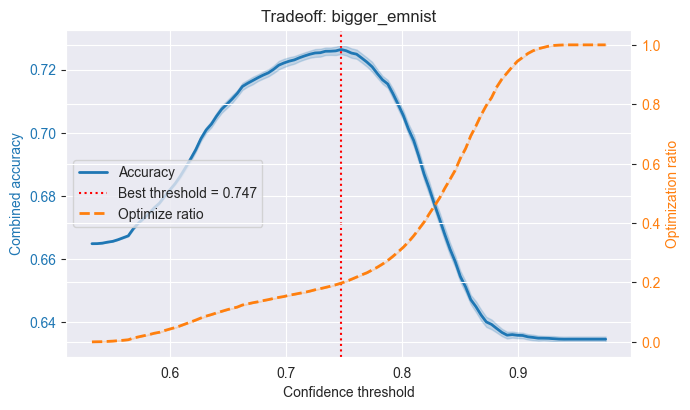


✅ Best threshold: 0.7475
 → Combined accuracy: 0.7263
 → Optimization ratio: 19.76%


In [67]:
import os
import numpy as np
import torch
import tqdm
import matplotlib.pyplot as plt
from typing import Dict, Optional
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F


def _tensor_to_1d_numpy(t: torch.Tensor) -> np.ndarray:
    """Move tensor to cpu and return flattened 1d numpy array (batch dimension)."""
    if t is None:
        return None
    t = t.detach().cpu()
    # if shape is (batch, 1) or (...,1) reduce last dim
    if t.ndim > 1 and t.shape[-1] == 1:
        t = t.squeeze(-1)
    return t.reshape(-1).numpy()


@torch.no_grad()
def calculate_spatial_confidences_and_cache(
    spatial_transformer,
    optimizer,
    best_problem,
    conf_module,
    model,
    test_loader_transformed,
    device,
    n_runs: int = 5,
    cache_path: str = "cached_spatial_confidences.npz",
    force_recompute: bool = False,
) -> Dict[str, np.ndarray]:
    """
    Calculates spatial transformer vs optimizer confidences on transformed data only.
    - Ensures the same confidence metric (max softmax prob) is used for both spatial and optimized outputs
      when possible.
    - Handles multiple stochastic optimizer runs (returns stacked arrays shape (n_samples, n_runs)).
    - Caches results.
    """
    if os.path.exists(cache_path) and not force_recompute:
        print(f"✅ Loading cached results from {cache_path}")
        return dict(np.load(cache_path, allow_pickle=True))

    spatial_transformer.eval()
    model.eval()

    # --- Spatial transformer (no optimization) ---
    print("=== Evaluating spatial transformer (no optimization) ===")
    confs_list = []
    correct_list = []
    st_acc = 0

    for data, target in tqdm.tqdm(test_loader_transformed, desc="Spatial transformer"):
        data, target = data.to(device), target.to(device)
        data_transformed = spatial_transformer.transform_input(data)

        # conf_module may return (conf, logits) or (None, logits)
        conf_tensor, output_logits = conf_module(data_transformed)
        # If conf_module returned None or non-probabilistic values, compute max softmax prob from logits
        if conf_tensor is None:
            if output_logits is None:
                # fallback: use model logits
                output_logits = model(data_transformed)
            probs = F.softmax(output_logits, dim=-1)
            conf_tensor = probs.max(dim=-1).values  # shape (batch,)
        else:
            # If conf_tensor is logits-like or probabilities, try to make it 1d
            # We assume conf_tensor is already comparable. If it's logits, user should modify conf_module.
            pass

        # Decide final output logits for accuracy if not provided
        if output_logits is None:
            output_logits = model(data_transformed)

        confs_list.append(_tensor_to_1d_numpy(conf_tensor))
        same = output_logits.argmax(dim=-1).eq(target)
        correct_list.append(same.detach().cpu().numpy())
        st_acc += same.sum().item()

    st_acc /= len(test_loader_transformed.dataset)
    confs = np.concatenate(confs_list, axis=0)
    correct = np.concatenate(correct_list, axis=0)

    print(f"Spatial transformer accuracy: {st_acc:.4f}")

    # --- SHGO optimizer (multiple runs) ---
    print(f"\n=== Running optimizer ({n_runs} runs) ===")
    all_conf_search = []
    all_correct_search = []
    opt_accs = []

    for run_idx in range(n_runs):
        print(f"\n--- Run {run_idx + 1}/{n_runs} ---")
        conf_search_list = []
        correct_search_list = []
        opt_acc = 0

        for data, target in tqdm.tqdm(test_loader_transformed, desc=f"Optimizer run {run_idx+1}"):
            data, target = data.to(device), target.to(device)

            best_param, best_error, _ = optimizer.optimize(best_problem, data)
            x_optimized = best_problem.transform_sequence.transform(data, best_param)

            conf_values, best_logits = conf_module(x_optimized)


            # else we accept conf_values as returned by conf_module

            # If best_logits still None, compute for accuracy
            if best_logits is None:
                best_logits = model(x_optimized)

            conf_search_list.append(_tensor_to_1d_numpy(conf_values))
            best_class = best_logits.argmax(dim=-1)
            same = best_class.squeeze(-1).eq(target)
            correct_search_list.append(same.detach().cpu().numpy())
            opt_acc += same.sum().item()

        opt_acc /= len(test_loader_transformed.dataset)
        opt_accs.append(opt_acc)

        # each run returns a vector per-sample
        conf_search = np.concatenate(conf_search_list, axis=0)
        correct_search = np.concatenate(correct_search_list, axis=0)

        all_conf_search.append(conf_search)
        all_correct_search.append(correct_search)

        print(f"Optimizer accuracy (run {run_idx+1}): {opt_acc:.4f}")

    # Stack runs -> shape (n_runs, n_samples) then transpose to (n_samples, n_runs)
    all_conf_search = np.stack(all_conf_search, axis=0).T  # (n_samples, n_runs)
    all_correct_search = np.stack(all_correct_search, axis=0).T  # (n_samples, n_runs)

    # Trim to min length to be safe (should be same length if loader deterministic)
    n = min(len(confs), all_conf_search.shape[0])
    confs = confs[:n]
    correct = correct[:n]
    all_conf_search = all_conf_search[:n, :]
    all_correct_search = all_correct_search[:n, :]

    # Compute AUCs: spatial and per-run optimizer AUCs
    auc_st = roc_auc_score(1 - correct, confs)
    aucs_opt = []
    for run_idx in range(all_conf_search.shape[1]):
        try:
            auc_run = roc_auc_score(1 - all_correct_search[:, run_idx], all_conf_search[:, run_idx])
        except ValueError:
            auc_run = float("nan")
        aucs_opt.append(auc_run)
    aucs_opt = np.array(aucs_opt)
    auc_opt_mean = np.nanmean(aucs_opt)
    auc_opt_std = np.nanstd(aucs_opt, ddof=1) if np.sum(~np.isnan(aucs_opt)) > 1 else 0.0

    print(f'\nAUC spatial transformer: {auc_st:.4f}')
    print(f'AUC optimizer per-run mean: {auc_opt_mean:.4f} ± {auc_opt_std:.4f}')
    print(f'Optimizer per-run AUCs: {aucs_opt}')

    results = {
        "confs": confs,
        "correct": correct,
        "conf_search": all_conf_search,       # shape (n_samples, n_runs)
        "correct_search": all_correct_search, # shape (n_samples, n_runs)
        "st_acc": np.array([st_acc]),
        "opt_accs": np.array(opt_accs),
        "auc_st": np.array([auc_st]),
        "auc_opt_runs": aucs_opt,
        "auc_opt_mean": np.array([auc_opt_mean]),
        "auc_opt_std": np.array([auc_opt_std]),
    }

    np.savez_compressed(cache_path, **results)
    print(f"\n💾 Results cached to: {cache_path}")

    return results


def plot_spatial_confidence_threshold_results(
    results: dict,
    dataset_name: str = "Dataset",
    use_only_improved: bool = True,
    relative_improvement: float = 0.0,
    ci_multiplier: float = 1.96,
    lower_quantile: float = 0.0,
    upper_quantile: float = 1.0,
    plot_ratio: bool = True,
    save_path: Optional[str] = None,
    spatial_acc_in_dist: Optional[float] = None,
):
    """
    Plot accuracy vs threshold and optimization ratio, using consistent confidence scale.
    Assumes results["conf_search"] shape = (n_samples, n_runs).
    """
    confs = results["confs"]
    correct = results["correct"]
    conf_search = results["conf_search"]  # (n_samples, n_runs)
    correct_search = results["correct_search"]  # (n_samples, n_runs)

    n_runs = conf_search.shape[1]

    # Combined thresholds over both spatial confs and optimizer confs (within quantiles)
    # Clip confs by quantiles optionally
    low = np.quantile(confs, lower_quantile)
    high = np.quantile(confs, upper_quantile)
    # Use global min/max from both sources for thresholds
    vmin = min(confs.min(), conf_search.min())
    vmax = max(confs.max(), conf_search.max())
    thresholds = np.linspace(vmin, vmax, num=100)

    # Calculate metrics for each run
    acc_tradeoff_runs = []
    optimize_ratio_runs = []

    for run_idx in range(n_runs):
        conf_s = conf_search[:, run_idx]
        correct_s = correct_search[:, run_idx]

        # Ensure same length
        n = min(len(confs), len(conf_s))
        c = confs[:n]
        corr = correct[:n]
        c_s = conf_s[:n]
        corr_s = correct_s[:n]

        acc_trade = []
        opt_ratio = []

        for thresh in thresholds:
            use_st = c >= thresh
            use_search = ~use_st

            opt_ratio.append(use_search.mean())


            if use_only_improved:
                # Only use optimizer when it actually improves confidence (in same metric)
                improved = c_s >= c
                if relative_improvement > 0.0:
                    conf_range = c.max() - c.min()
                    if conf_range > 0:
                        rel_imp = (c_s - c) / conf_range
                        improved = np.logical_and(improved, rel_imp >= relative_improvement)
                use_search = np.logical_and(use_search, improved)

            correct_combined = np.where(use_search, corr_s, corr)
            acc_trade.append(np.mean(correct_combined))

        acc_tradeoff_runs.append(acc_trade)
        optimize_ratio_runs.append(opt_ratio)

    acc_tradeoff_runs = np.array(acc_tradeoff_runs)  # (n_runs, n_thresholds)
    optimize_ratio_runs = np.array(optimize_ratio_runs)

    # Mean and confidence intervals
    acc_mean = acc_tradeoff_runs.mean(axis=0)
    ratio_mean = optimize_ratio_runs.mean(axis=0)

    if n_runs > 1:
        acc_se = acc_tradeoff_runs.std(axis=0, ddof=1) / np.sqrt(n_runs)
        ratio_se = optimize_ratio_runs.std(axis=0, ddof=1) / np.sqrt(n_runs)
        acc_lower = acc_mean - ci_multiplier * acc_se
        acc_upper = acc_mean + ci_multiplier * acc_se
        ratio_lower = ratio_mean - ci_multiplier * ratio_se
        ratio_upper = ratio_mean + ci_multiplier * ratio_se
    else:
        acc_lower = acc_upper = acc_mean
        ratio_lower = ratio_upper = ratio_mean

    # Plot
    fig, ax1 = plt.subplots(figsize=(7, 4))
    color1 = 'tab:blue'
    color2 = 'tab:orange'

    ax1.set_xlabel("Confidence threshold")
    ax1.set_ylabel("Combined accuracy", color=color1)
    ax1.plot(thresholds, acc_mean, color=color1, label="Accuracy", linewidth=2)
    ax1.fill_between(thresholds, acc_lower, acc_upper, color=color1, alpha=0.2)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True)

    if plot_ratio:
        ax2 = ax1.twinx()
        ax2.set_ylabel("Optimization ratio", color=color2)
        ax2.plot(thresholds, ratio_mean, color=color2, linestyle='--', label="Optimize ratio", linewidth=2)
        ax2.fill_between(thresholds, ratio_lower, ratio_upper, color=color2, alpha=0.2)
        ax2.tick_params(axis='y', labelcolor=color2)

    # Best threshold
    best_idx = np.nanargmax(acc_mean)
    best_thresh = thresholds[best_idx]
    best_acc = acc_mean[best_idx]
    best_ratio = ratio_mean[best_idx]

    ax1.axvline(best_thresh, color='red', linestyle=':', label=f'Best threshold = {best_thresh:.3f}')

    if spatial_acc_in_dist is not None:
        ax1.axhline(spatial_acc_in_dist, color='green', linestyle='--', label='Spatial acc (in-dist)', alpha=0.7)

    fig.tight_layout()
    plt.title(f"Tradeoff: {dataset_name}")

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    if plot_ratio:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left")
    else:
        ax1.legend(loc="center left")

    if save_path:
        plt.savefig(save_path)
    plt.show()

    print(f"\n✅ Best threshold: {best_thresh:.4f}")
    print(f" → Combined accuracy: {best_acc:.4f}")
    print(f" → Optimization ratio: {best_ratio*100:.2f}%")

# Usage:
cache_path = os.path.join(
    results_dir_path,
    f"spatial_transformer_confidence_cache_{dataset}_{architecture}.npz"
)


results = calculate_spatial_confidences_and_cache(
    spatial_transformer=spatial_transformer,
    optimizer=optimizer,
    best_problem=best_problem,
    conf_module=best_problem.confidence_module,
    model=model,
    test_loader_transformed=test_loader_transformed,
    device=device,
    n_runs=5,
    cache_path=cache_path,
    force_recompute=False,
)

plot_spatial_confidence_threshold_results(
    results=results,
    dataset_name=dataset,
    use_only_improved=True,
    relative_improvement=0.0,
    save_path=os.path.join(fig_path, f"spatial_transformer_threshold_plot_{dataset}_{architecture}.pdf"),
)

In [68]:
from search.shgo import SHGO

optimizer_120 = SHGO(initial_samples=120-27, local_runs=3, local_max_steps=4,local_opt_kwargs={"lr":0.1})
if dataset == "tu_berlin":
    optimizer_120 = SHGO(initial_samples=120,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})

from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search
from utils.transformation_problem import TransformationProblem

architecture_half = architecture+"_half"

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


energy_model2_half = get_network(dataset_info,architecture_half, num_classes=1).to(device)
from experiment_thesis.main import train_or_load_energy_model
negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    = transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)
energy_conf_half = train_or_load_energy_model(
    energy_model2_half, model_dir_path, f"{modelname}_energy2_half", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)

energy_conf_half.to(device).eval()
problem_energy_half = TransformationProblem(energy_conf_half, transform_seq,                                              consolidate_method="consolidate_simple",max_batch_size=dataset_info.batch_size_search)


def savepath_later_layer(label: str) -> str:
    model_dir_path = os.path.join(current_path, "experiment_files", "models")
    embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
    # Add results dir and helper for save paths
    results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparison_supervised_methods")
    os.makedirs(results_dir_path, exist_ok=True)

    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

res_120 = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer_120, problem=problem_energy_half,
    test_loader=test_loader, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath_later_layer("learned_energy_confidence_half_transformed_120"), show_progress=True,
    repeats=5)

res_120_real_data = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer_120, problem=problem_energy_half,
    test_loader=test_loader, max_batch_override=dataset_info.batch_size_search, show_progress=True, save_path=
    savepath_later_layer("learned_energy_confidence_half_transformed_120_untransformed"),
    repeats=5)



del energy_model2_half
del energy_conf_half

print(res_120["accuracy_mean"])

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_emnist_bigger_extended_resnet_small_energy2_half_energy_conf_best.safetensors
Model has non-negative constraint: False


0.755553126335144


✅ Loading cached results from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_unsupervised\spatial_transformer_confidence_cache_energy_half_bigger_emnist_bigger_extended_resnet_small.npz


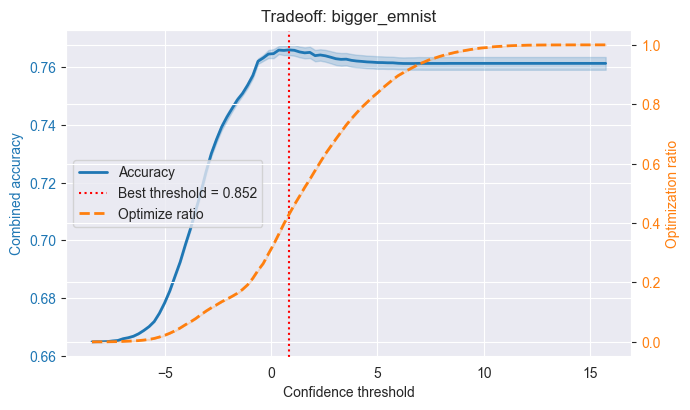


✅ Best threshold: 0.8520
 → Combined accuracy: 0.7660
 → Optimization ratio: 43.01%


In [69]:
results = calculate_spatial_confidences_and_cache(
    spatial_transformer=spatial_transformer,
    optimizer=optimizer_120,
    best_problem=problem_energy_half,
    conf_module=problem_energy_half.confidence_module,
    model=model,
    test_loader_transformed=test_loader_transformed,
    device=device,
    n_runs=5,
    cache_path=os.path.join(
        results_dir_path,
        f"spatial_transformer_confidence_cache_energy_half_{dataset}_{architecture}.npz"
    ),
    force_recompute=False,
)
plot_spatial_confidence_threshold_results(
    results=results,
    dataset_name=dataset,
    use_only_improved=True,
    relative_improvement=0.0,
    save_path=os.path.join(
        fig_path,
        f"spatial_transformer_threshold_plot_energy_half_{dataset}_{architecture}.pdf"
    ),
)

✅ Loading cached results from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_unsupervised\spatial_transformer_confidence_cache_spatial_bigger_emnist_bigger_extended_resnet_small.npz


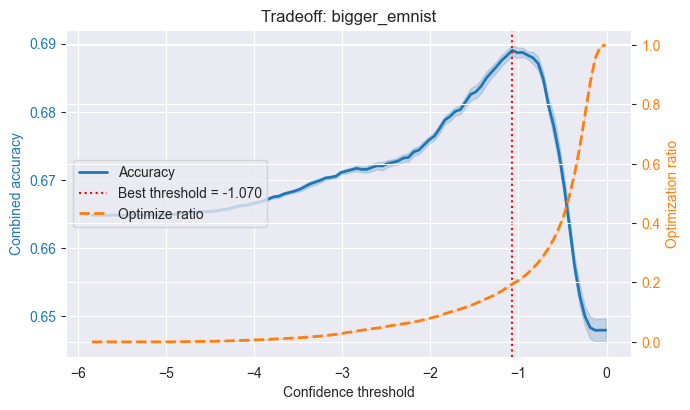


✅ Best threshold: -1.0701
 → Combined accuracy: 0.6890
 → Optimization ratio: 19.46%


In [70]:
results = calculate_spatial_confidences_and_cache(
    spatial_transformer=spatial_transformer,
    optimizer=optimizer,
    best_problem=problem_spatial,
    conf_module=problem_spatial.confidence_module,
    model=model,
    test_loader_transformed=test_loader_transformed,
    device=device,
    n_runs=5,
    cache_path=os.path.join(
        results_dir_path,
        f"spatial_transformer_confidence_cache_spatial_{dataset}_{architecture}.npz"
    ),
    force_recompute=False,
)
plot_spatial_confidence_threshold_results(
    results=results,
    dataset_name=dataset,
    use_only_improved=True,
    relative_improvement=0.0,
    save_path=os.path.join(
        fig_path,
        f"spatial_transformer_threshold_plot_spatial_{dataset}_{architecture}.pdf"
    ),
)